# NB07 — Trigger Validation: GloFAS Ensemble Forecasts vs Impact-Space Thresholds

## Purpose
Validate whether GloFAS ensemble forecasts would have triggered an early warning
for the reference flood events, at each spatial level (municipality / province /
watershed) and each lead time (1–15 days before peak).

## Key design
Thresholds are in **impact space** (people affected), derived from NB05 OEP curves:
- RP2 threshold = OEP curve at 2-year return period per unit
- RP5 threshold = OEP curve at 5-year return period per unit
- RP10 threshold = OEP curve at 10-year return period per unit

The full NB04 pipeline runs **only for flood-triggering ensemble members** identified
by the same spatial connectivity rule as NB04:
  discharge → RP per cell → connected-component patch area ≥ A_MIN_KM2

## Execution order
**NB05 must run first** (generates `oep_curves_all_units.json`)

## Data availability
- EV_ULYSSES2020: GloFAS reforecast (11 members, 2003–2022) ✓
- EV_MARCE2024 / EV_UWAN2025 / EV_NEM2025: operational archive (Cagayan workflow) ✓
- EV_EGAY2023 / EV_Kristine2024: operational archive (benchmark events — commented out, for other study areas)

The notebook is **dynamic**: add/remove/comment entries in the `EVENTS` dict in Cell 1
to switch between 2, 3, 5 or any number of events.

## CDS download guide (operational forecasts)
```python
import cdsapi
c = cdsapi.Client()
for init_date in pd.date_range(peak_date - pd.Timedelta(days=15), peak_date - pd.Timedelta(days=1)):
    c.retrieve("cems-glofas-forecast", {
        "system_version": "operational",
        "variable": "river_discharge_in_the_last_24_hours",
        "product_type": "ensemble_perturbed_forecasts",
        "year": str(init_date.year), "month": f"{init_date.month:02d}",
        "day": f"{init_date.day:02d}",
        "leadtime_hour": [str(h) for h in range(24, 361, 24)],
        "area": [18, 121, 17, 122],  # [N, W, S, E] — adjust per basin
        "format": "grib",
    }, str(OPR_RAW_ROOT / EVENT_ID / f"{init_date:%Y-%m-%d}" / "data.grib"))
```
Store as: `{OPR_RAW_ROOT}/{EVENT_ID}/{YYYY-MM-DD}/data.grib`
Example:  `G:\My Drive\...\Operational\EV_MARCE2024\2024-11-11\data.grib`

**GRIB format (operational)**: 50 perturbed members (perturbationNumbers 1–50),
steps 24–360 h (15 lead days), shortName=`dis24`, one init date per file.

In [1]:
# =============================================================================
# NB07 — CONFIG
# =============================================================================
from pathlib import Path
from philflood.ops.config import load_run_config

# ── Paths ─────────────────────────────────────────────────────────────────────
REPO_ROOT       = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL")
PROCESSED_ROOT  = REPO_ROOT / "data" / "processed"
RAW_ROOT        = REPO_ROOT / "data" / "raw"

_cfg     = load_run_config(PROCESSED_ROOT, auto_select_latest=True)
basin_id = _cfg.get("basin_id", "Cagayan_01")
run_tag  = _cfg.get("run_tag",  "UNKNOWN")

NB5_OUT_DIR      = PROCESSED_ROOT / "Riskprofiles"
RFC_EXTRACT_ROOT = RAW_ROOT / "glofas" / "reforecast" / "version_4_0" / \
                   "consolidated" / "discharge" / "grib2" / "area_35_63_4_131"
# Operational forecast GRIBs live on Google Drive.
# Layout: {OPR_RAW_ROOT}/{EVENT_ID}/{YYYY-MM-DD}/data.grib  (one file per init date)
OPR_RAW_ROOT     = Path(r"G:\My Drive\GLOFAS_ImpactFloodForecasting_PHL\data\raw\glofas\forecast\Operational")

# ── Events ────────────────────────────────────────────────────────────────────
# Dynamic: the notebook processes whatever events are active (uncommented) here.
# Add, remove, or comment out entries to run with 2, 3, or more events.
EVENTS = {
    "EV_ULYSSES2020": {
        "label":     "TY Ulysses — Nov 2020",
        "peak_date": "2020-11-12",
        "mode":      "reforecast",
    },
    "EV_MARCE2024": {
        "label":     "TY Marce — Nov 2024",
        "peak_date": "2024-11-12",
        "mode":      "operational",
    },
    "EV_UWAN2025": {
        "label":     "STY Uwan — Nov 2025",
        "peak_date": "2025-11-11",
        "mode":      "operational",
    },
    "EV_NEM2025": {
        "label":     "NE Monsoon — Dec 2025",
        "peak_date": "2025-11-29",
        "mode":      "operational",
    },
    # ── Benchmark events for alternative study areas ───────────────────────────
    # Uncomment when running for the relevant basin (not Cagayan_01).
    # "EV_EGAY2023": {
    #     "label":     "TY Egay — Jul 2023",
    #     "peak_date": "2023-07-25",   # EDIT: confirm date for target basin
    #     "mode":      "operational",
    # },
    # "EV_Kristine2024": {
    #     "label":     "TY Kristine — Oct 2024",
    #     "peak_date": "2024-10-22",   # EDIT: confirm date for target basin
    #     "mode":      "operational",
    # },
}

# ── Analysis parameters ───────────────────────────────────────────────────────
LEAD_TIMES_DAYS  = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
PEAK_BUFFER_DAYS = 3                   # window_end = peak_date + N days

# Flood detection (same as NB04)
T0_YEARS         = 2.0                 # RP threshold: cell is "active" if RP >= T0
A_MIN_KM2        = 100.0              # event = largest contiguous active patch >= this
CC_CONNECTIVITY  = 2                   # 2 = 8-neighbour (Moore), 1 = 4-neighbour

# Impact pipeline
DEPTH_THRESHOLD_M = 0.02              # flood depth threshold for population exposure
REGRID_METHOD    = "bilinear"          # interpolation method for RP -> JRC depth regrid
RFC_SHORTNAME     = "dis24"           # GRIB variable shortname

# Impact-space RP thresholds to evaluate (read from OEP curve)
FLOOD_DETECT_RPS  = [2, 5, 10, 20]

# Trigger probability reference line
TRIGGER_PROB_LINE = 0.50              # 50% of ensemble = recommended trigger

print(f"Basin: {basin_id} | Run: {run_tag}")
print(f"OPR root: {OPR_RAW_ROOT}")
print(f"RFC root: {RFC_EXTRACT_ROOT}")
# ── Checkpoint config ────────────────────────────────────────────
CHECKPOINT_DIR = PROCESSED_ROOT / "nb07_checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESUME_FROM_CHECKPOINT = True   # set False to force full rerun (clears nothing)

Basin: Cagayan_01 | Run: 2026-01-19_calib-test
OPR root: G:\My Drive\GLOFAS_ImpactFloodForecasting_PHL\data\raw\glofas\forecast\Operational
RFC root: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\glofas\reforecast\version_4_0\consolidated\discharge\grib2\area_35_63_4_131


In [2]:
# =============================================================================
# NB07 — Imports + Load Inputs
# =============================================================================
import json
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from pathlib import Path
from typing import Dict, List, Tuple, Optional

# ── EVT1 parameters (discharge GPD per GloFAS cell) ──────────────────────────
# NB01 outputs evt_pot_calibration.parquet; we transform it to NB07 expected schema
_evt_parquet = _cfg.get("evt_params_parquet", "")
if _evt_parquet and Path(_evt_parquet).exists():
    evt_nraw = pd.read_parquet(_evt_parquet)
    # Rename NB01 column names to NB04/NB07 convention (same as NB04 Cell 4)
    _col_map = {
        "virtual_gauge_id": "cell_id",
        "threshold_m3s":    "u",
        "lambda_events_per_year": "lam",
        "gpd_xi":   "xi",
        "gpd_sigma": "sigma",
    }
    evt_params = evt_nraw.rename(columns={k: v for k, v in _col_map.items() if k in evt_nraw.columns}).copy()
    # Extract lat/lon from cell_id (format: CELL__lat_XX.XXXX__lon_YY.YYYY)
    if "lat" not in evt_params.columns:
        import re as _re
        def _parse_ll(cid):
            m = _re.search(r"lat_([-\d.]+)__lon_([-\d.]+)", str(cid))
            return (float(m.group(1).rstrip(".")), float(m.group(2).rstrip("."))) if m else (float("nan"), float("nan"))
        _ll = evt_params["cell_id"].astype(str).apply(_parse_ll)
        evt_params["lat"] = [v[0] for v in _ll]
        evt_params["lon"] = [v[1] for v in _ll]
    print(f"✅ EVT1 params: {len(evt_params)} cells | cols: {list(evt_params.columns)}")
else:
    raise FileNotFoundError(f"evt_params_parquet not found: {_evt_parquet!r}\nRun NB01 first")

# ── NB05 OEP curves for all units ─────────────────────────────────────────────
_oep_all_path = NB5_OUT_DIR / "oep_curves_all_units.json"
if _oep_all_path.exists():
    try:
        oep_all   = json.loads(_oep_all_path.read_text(encoding="utf-8"))
        RP_REPORT = oep_all.get("rp_report", [])
        unit_recs = oep_all.get("units", [])          # list of dicts with unit/oep_rl/aep_rl etc.
        unit_names = [r["unit"] for r in unit_recs] if unit_recs else []
        oep_rl_by_unit = {r["unit"]: np.array(r["oep_rl"]) for r in unit_recs} if unit_recs else {}
        aep_rl_by_unit = {r["unit"]: np.array(r["aep_rl"]) for r in unit_recs} if unit_recs else {}
        print(f"✅ OEP curves: {len(unit_names)} units | RP grid: {RP_REPORT}")
    except Exception as exc:
        raise FileNotFoundError(f"NB05 OEP JSON load failed: {exc}\nRun NB05 first with oep_curves_all_units.json export")
else:
    raise FileNotFoundError(f"NB05 output not found: {_oep_all_path}\nRun NB05 first (updated version with oep_curves_all_units.json export)")

# ── ADM3 GeoJSON ──────────────────────────────────────────────────────────────
_adm3_path = _cfg.get("adm3_geojson", "")
if _adm3_path and Path(_adm3_path).exists():
    adm3_gdf = gpd.read_file(_adm3_path).to_crs("EPSG:4326")
    print(f"✅ ADM3: {len(adm3_gdf)} municipalities")
else:
    warnings.warn(f"ADM3 GeoJSON not found: {_adm3_path!r}")
    adm3_gdf = gpd.GeoDataFrame()

# ── HydroBASINS L12 for basin cell selection ──────────────────────────────────
_l12_path = _cfg.get("hydrobasins_l12", str(RAW_ROOT / "vectors" / "hydrobasins" / "australasia" / "hybas_au_lev01-12_v1c" / "hybas_au_lev12_v1c.shp"))
if _l12_path and Path(_l12_path).exists():
    l12_gdf = gpd.read_file(_l12_path).to_crs("EPSG:4326")
    print(f"✅ HydroBASINS L12: {len(l12_gdf)} polygons")
else:
    warnings.warn(f"HydroBASINS L12 not found: {_l12_path!r} — cell selection may be limited")
    l12_gdf = None

# ── Resource paths (JRC, WorldPop) ────────────────────────────────────────────
JRC_ROOT     = Path(_cfg.get("jrc_root",      str(RAW_ROOT / "jrc_flood_maps")))
WORLDPOP_TIF = Path(_cfg.get("worldpop_raster", str(RAW_ROOT / "worldpop" / "PHL" / "phl_pop_2025_CN_100m_R2025A_v1.tif")))

if not JRC_ROOT.exists():
    warnings.warn(f"JRC flood maps root not found: {JRC_ROOT}")
if not WORLDPOP_TIF.exists():
    warnings.warn(f"WorldPop raster not found: {WORLDPOP_TIF}")

print(f"JRC root : {JRC_ROOT}")
print(f"WorldPop : {WORLDPOP_TIF}")


✅ EVT1 params: 1024 cells | cols: ['cell_id', 'u', 'threshold_source', 'run_length_days', 'lam', 'coverage_years', 'xi', 'sigma', 'lat', 'lon']
✅ OEP curves: 263 units | RP grid: [1.0, 2.0, 5.0, 10.0, 20.0, 25.0, 50.0, 75.0, 100.0, 200.0, 500.0]
✅ ADM3: 1647 municipalities
✅ HydroBASINS L12: 83929 polygons
JRC root : C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\jrc_flood_maps
WorldPop : C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\worldpop\PHL\phl_pop_2025_CN_100m_R2025A_v1.tif


In [3]:
from __future__ import annotations   # defer all type-annotation evaluation

# ── Imports required by NB04 Cells 2/3/26 (normally in NB04 Cell 1 CONFIG) ──
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import rasterio
from rasterio.transform import Affine, from_bounds
from rasterio.warp import reproject, Resampling
from rasterio.merge import merge
from contextlib import ExitStack
from climada_petals.hazard.rf_glofas.transform_ops import (
    regrid        as petals_regrid,
    flood_depth   as petals_flood_depth,
    apply_flopros as petals_apply_flopros,
)
from climada_petals.hazard.rf_glofas.setup import download_flopros_database
from shapely.geometry import box as sbox
from scipy import stats
from scipy.ndimage import label, generate_binary_structure
from typing import Dict, List, Optional, Tuple
from pathlib import Path

# ── Constants used inside helper function bodies ──
RP_CAP         = 500.0    # discharge_to_return_period cap (years)
DECLUSTER_DAYS = 5        # peak_pick declustering window (days)
# OUTPUT_DIR fallback — only used if USE_FLOPROS=True
OUTPUT_DIR = PROCESSED_ROOT / "Forecast Skill"

def _log(msg: str):
    print(f"[NB7] {msg}")

# ── Per-notebook caches (reset on Cell 3 re-run) ────────────────────────────────────────────
_GRIB_IDX_CACHE: dict = {}    # {(path_str, shortname): (msg_index, inits, steps, members, tmpl)}
_FALLBACK_WARNED: set = set() # {(path_str, init_dt_str)} — avoid duplicate fallback log lines
_CACHED_REGRIDDER = None       # xe.Regridder, built on first compute_depth_from_rp_nb3 call
_CACHED_REGRIDDER_SHAPE = None # (src_nlat, src_nlon) — invalidate if source grid changes




# =============================================================================
# NB07 — Section 2: Helper Functions
# [A] Reused verbatim from NB04 Cell 2 (HELPERS)
# [B] Reused verbatim from NB04 Cell 3 (CLIMADA-PETALS depth engine)
# [C] Reused verbatim from NB04 Cell 26 (GRIB utilities)
# [D] NB05 utilities (enforce_monotone_nondec, invert_oep_curve_to_rp)
# [E] NB07-specific new functions
# =============================================================================

# [A] NB04 Cell 2 — HELPERS
# =========================
# Section 1 — HELPERS
# =========================

import re
from rasterio import features as rio_features

# _log() is already defined in Section 0 CONFIG

def parse_cell_coords(cell_id: str) -> Tuple[float, float]:
    """Extract lat/lon from cell_id following pattern: CELL__lat_XX.XXXX__lon_YY.YYYY"""
    m = re.search(r"lat_([-\d.]+)__lon_([-\d.]+)", str(cell_id))
    if not m:
        raise ValueError(f"Cannot parse lat/lon from cell_id={cell_id}")
    return float(m.group(1).rstrip(".")), float(m.group(2).rstrip("."))

# =========================================================================
# CORE HELPER FUNCTIONS (from NB9999 + 04_script)
# =========================================================================

def gpd_exceedance_rate(q: np.ndarray, u: np.ndarray, sigma: np.ndarray, xi: np.ndarray, lam: np.ndarray) -> np.ndarray:
    """Return exceedance rate (events/year) for discharge q using POT/GPD params."""
    q, u, sigma, xi, lam = np.broadcast_arrays(
        np.asarray(q, dtype=float), np.asarray(u, dtype=float), np.asarray(sigma, dtype=float),
        np.asarray(xi, dtype=float), np.asarray(lam, dtype=float),
    )
    y = (q - u) / sigma
    y = np.maximum(y, 0.0)
    near0 = np.isclose(xi, 0.0)
    surv = np.empty_like(y, dtype=float)
    surv[near0] = np.exp(-y[near0])
    surv[~near0] = np.power(1.0 + xi[~near0] * y[~near0], -1.0 / xi[~near0])
    rate = lam * surv
    return np.clip(rate, 1e-12, None)

def discharge_to_return_period(q: np.ndarray, u: np.ndarray, sigma: np.ndarray, xi: np.ndarray, lam: np.ndarray, rp_cap: float = 500.0) -> np.ndarray:
    """Convert discharge to return period (years) using exceedance rate."""
    rate = gpd_exceedance_rate(q=q, u=u, sigma=sigma, xi=xi, lam=lam)
    rp = 1.0 / rate
    return np.clip(rp, 1.0, rp_cap)

def peak_pick(series: pd.Series, threshold: float, decluster_days: int) -> pd.DatetimeIndex:
    """
    Plateau-safe peak picking with declustering.
    A peak is any point equal to the centered 3-day rolling max.
    """
    s = series.dropna().sort_index()
    if s.empty:
        return pd.DatetimeIndex([])

    roll_max = s.rolling(window=3, center=True, min_periods=1).max()
    candidates = s[(s >= threshold) & (s == roll_max)].copy()
    if candidates.empty:
        return pd.DatetimeIndex([])

    # decluster: pick highest candidates first, then block ±decluster_days
    candidates = candidates.sort_values(ascending=False)
    selected = []
    taken = pd.Series(False, index=s.index)

    for t, _ in candidates.items():
        if taken.loc[t]:
            continue
        selected.append(t)
        win = (s.index >= t - pd.Timedelta(days=decluster_days)) & (s.index <= t + pd.Timedelta(days=decluster_days))
        taken.loc[win] = True

    return pd.DatetimeIndex(sorted(selected))

def _earth_cell_area_km2(lat_deg: np.ndarray, dlat_deg: float, dlon_deg: float) -> np.ndarray:
    """
    Approx area of lat-lon cell at latitude lat_deg, in km².
    Works well for 0.05° grids.
    """
    R = 6371.0  # km
    lat_rad = np.deg2rad(lat_deg)
    dlat = np.deg2rad(dlat_deg)
    dlon = np.deg2rad(dlon_deg)
    return (R * R) * dlat * dlon * np.cos(lat_rad)


def compute_amax_series_from_discharge(
    discharge_ts: pd.DataFrame,
    evt_params: pd.DataFrame,
    support_cells_present: List[str],
    grid_index: np.ndarray,
    area_grid_km2: np.ndarray,
    t0_years: float,
    connectivity: int = 1,
) -> pd.DataFrame:
    """
    Compute connected-component metric on the GloFAS grid:

    For each day t:
      - compute RP per support cell from EVT1 POT-Poisson-GPD
      - active cells: RP >= t0_years
      - A_max(t): area (km²) of largest contiguous active component
      - n_active(t): number of active support cells (for diagnostics)

    Returns DataFrame with columns: ["Amax_km2", "n_active_cells"]
    """
    cells = [c for c in support_cells_present if c in discharge_ts.columns]
    if not cells:
        raise ValueError("No detection cells present in discharge_ts after masking.")

    p = evt_params.set_index("cell_id").loc[cells]
    Q = discharge_ts[cells].to_numpy()

    u = p["u"].to_numpy()[None, :]
    xi = p["xi"].to_numpy()[None, :]
    sigma = p["sigma"].to_numpy()[None, :]
    lam = p["lam"].to_numpy()[None, :]

    rp = discharge_to_return_period(Q, u, sigma, xi, lam, rp_cap=RP_CAP)
    active = (rp >= t0_years)  # shape (ntime, ncells)

    valid = (grid_index >= 0)
    if not np.any(valid):
        raise ValueError("grid_index has no valid cells (all -1).")

    # Connected-component structure
    structure = generate_binary_structure(2, connectivity)

    ntime = active.shape[0]
    amax = np.zeros(ntime, dtype=float)
    n_active = active.sum(axis=1).astype(int)

    # Vectorized lookup mapping: grid_index gives which column in `cells` list belongs to each grid cell
    # For speed, we reuse a preallocated grid buffer
    for t in range(ntime):
        if n_active[t] == 0:
            continue

        g = np.zeros(grid_index.shape, dtype=bool)
        g[valid] = active[t, grid_index[valid]]

        if not g.any():
            continue

        labs, nlab = label(g, structure=structure)
        if nlab == 0:
            continue

        # sum area per label; label 0 = background
        areas = np.bincount(labs.ravel(), weights=area_grid_km2.ravel())
        amax[t] = float(np.max(areas[1:])) if len(areas) > 1 else 0.0

    out = pd.DataFrame(
        {"Amax_km2": amax, "n_active_cells": n_active},
        index=discharge_ts.index
    )
    return out

def auto_select_threshold(series: pd.Series, q_candidates: List[float], decluster_days: int, min_events: int, max_events: int) -> float:
    """Pick a POT threshold (quantile) producing a reasonable number of declustered events."""
    s = series.dropna().sort_index()
    best = None
    report = []
    for q in q_candidates:
        thr = float(s.quantile(q))
        peaks = peak_pick(s, threshold=thr, decluster_days=decluster_days)
        n = len(peaks)
        report.append((q, thr, n))
        if min_events <= n <= max_events:
            best = thr
            break
    if best is None:
        best = float(sorted(report, key=lambda x: abs(x[2] - min_events))[0][1])
    _log(f"Threshold scan (q, thr, n_peaks): " + ", ".join([f"{q:.2f}:{thr:.3f}:{n}" for q, thr, n in report]))
    _log(f"Selected threshold={best:.3f}")
    return best

def load_uparea_weights(cell_ids: List[str], uparea_file: Path) -> np.ndarray:
    """Load upstream area weights from netcdf, fallback to equal weights."""
    if not uparea_file.exists():
        warnings.warn(f"Uparea not found: {uparea_file}; using equal weights")
        return np.ones(len(cell_ids), dtype=float)
    ds = xr.open_dataset(uparea_file)
    var = None
    for v in ds.data_vars:
        vn = v.lower()
        if vn in {"uparea", "upstream_area"} or ("up" in vn and "area" in vn):
            var = v
            break
    if var is None:
        warnings.warn("No upstream-area-like var found; using equal weights")
        return np.ones(len(cell_ids), dtype=float)
    da = ds[var]
    lat_name = "latitude" if "latitude" in da.dims else ("lat" if "lat" in da.dims else None)
    lon_name = "longitude" if "longitude" in da.dims else ("lon" if "lon" in da.dims else None)
    if lat_name is None or lon_name is None:
        warnings.warn(f"Could not infer lat/lon dims in uparea; using equal weights")
        return np.ones(len(cell_ids), dtype=float)
    weights = []
    ds_lons = da[lon_name].values
    for cid in cell_ids:
        la, lo = parse_cell_coords(cid)
        if np.nanmax(ds_lons) > 180 and lo < 0:
            lo = lo + 360.0
        try:
            val = float(da.sel({lat_name: la, lon_name: lo}, method="nearest").values)
            if not np.isfinite(val) or val <= 0:
                val = 1.0
        except Exception:
            val = 1.0
        weights.append(val)
    return np.asarray(weights, dtype=float)


def build_province_watershed_mapping(
    unit_names: list,
    adm3_gdf: "gpd.GeoDataFrame",
    adm3_id_col: str,
    adm2_name_col: str,
) -> Tuple[np.ndarray, list, list]:
    """
    Build the municipality → province aggregation matrix (same as NB05).
    Returns: prov_mat (n_munis, n_provs), muni_names list, prov_names list.
    """
    muni_names = [u.split("::")[1] for u in unit_names if u.startswith("ADM3::")]
    prov_names = [u.split("::")[1] for u in unit_names if u.startswith("ADM2::")]
    if not muni_names or not prov_names:
        raise ValueError("unit_names must contain ADM3:: and ADM2:: entries")

    prov_set = set(prov_names)
    # map muni_name → province_name via GeoDataFrame
    name_col = None
    for col in adm3_gdf.columns:
        if "adm3" in col.lower() and "name" in col.lower():
            name_col = col
            break
    if name_col is None:
        raise ValueError(f"Cannot detect ADM3 name column in {list(adm3_gdf.columns)}")

    adm2_col = adm2_name_col
    muni_to_prov = {}
    for _, row in adm3_gdf.iterrows():
        mname = str(row[name_col])
        pname = str(row[adm2_col]) if adm2_col else ""
        muni_to_prov[mname] = pname

    prov_mat = np.zeros((len(muni_names), len(prov_names)), dtype=float)
    for j, mn in enumerate(muni_names):
        pn = muni_to_prov.get(mn, "")
        if pn in prov_names:
            k = prov_names.index(pn)
            prov_mat[j, k] = 1.0
    return prov_mat, muni_names, prov_names


def detect_flood_members(
    grib_path: Path,
    event_window_dates: pd.DatetimeIndex,
    basin_cells: list,
    evt_params_df: pd.DataFrame,
    grid_index: np.ndarray,
    area_grid_km2: np.ndarray,
    lat1d: np.ndarray,
    lon1d: np.ndarray,
    t0_years: float = 2.0,
    a_min_km2: float = 100.0,
    connectivity: int = 2,
    shortname: str = "dis24",
    init_dt: pd.Timestamp | None = None,
    _grbs=None,          # pre-opened pygrib handle (NB04 open-once pattern)
    _cached_index=None,  # pre-built (msg_index, inits, steps, members, tmpl)
) -> list:
    """
    For each ensemble member, apply the same vicinity flood rule as NB04:
      1. Compute RP per cell via EVT1 GPD
      2. active = (RP >= t0_years) per cell
      3. Label connected components with 8-neighbour (connectivity=2)
      4. Member triggers flood iff largest component area >= a_min_km2 at any timestep
    Returns list of perturbationNumber values for flood-triggering members.
    """
    from scipy.ndimage import label, generate_binary_structure

    import pygrib
    _own_handle = _grbs is None
    if _own_handle:
        try:
            _grbs = pygrib.open(str(grib_path))
        except Exception as exc:
            warnings.warn(f"Cannot open {grib_path}: {exc}")
            return []

    if _cached_index is not None:
        msg_index, _inits, _steps, member_ids, _tmpl, vt_lookup = _cached_index
    else:
        _idx_key = (str(grib_path), shortname)
        if _idx_key not in _GRIB_IDX_CACHE:
            msg_index, _inits, _steps, member_ids, _tmpl, vt_lookup = _build_msg_index(_grbs, shortname)
            _GRIB_IDX_CACHE[_idx_key] = (msg_index, _inits, _steps, member_ids, _tmpl, vt_lookup)
            _log(f"GRIB index: {len(msg_index)} messages | members: {sorted(member_ids)[:5]}...")
        else:
            msg_index, _inits, _steps, member_ids, _tmpl, vt_lookup = _GRIB_IDX_CACHE[_idx_key]

    # Resolve init_dt to nearest available if not present in GRIB
    if init_dt is not None:
        avail_inits = sorted(set(_dt_from_grib(dd, tt) for dd, tt in _inits))
        if init_dt not in avail_inits:
            nearest = min(avail_inits, key=lambda d: abs(d - init_dt))
            _fw_key = (str(grib_path), str(init_dt.date()))
            if _fw_key not in _FALLBACK_WARNED:
                _log(f"init {init_dt.date()} not in GRIB; using nearest: {nearest.date()} "
                     f"({abs((nearest - init_dt).days)}d offset)")
                _FALLBACK_WARNED.add(_fw_key)
            init_dt = nearest

    # Cell lat/lon arrays
    cell_coords = {c: parse_cell_coords(c) for c in basin_cells}
    ep_df = evt_params_df.set_index("cell_id") if "cell_id" in evt_params_df.columns else evt_params_df

    # member_ids already returned by _build_msg_index as sorted(members)

    # Pre-compute GRIB grid axes and cell lookup indices (constant across all messages)
    _tmpl_msg = _grbs.message(_tmpl)
    _lats2d_tmpl, _lons2d_tmpl = _tmpl_msg.latlons()
    grib_lat1d = _lats2d_tmpl[:, 0]
    grib_lon1d = _lons2d_tmpl[0, :]
    _cell_lats = np.array([cell_coords[c][0] for c in basin_cells])
    _cell_lons = np.array([cell_coords[c][1] for c in basin_cells])
    lat_idx    = _nearest_index_1d(grib_lat1d, _cell_lats)
    lon_idx    = _nearest_index_1d(grib_lon1d, _cell_lons)

    structure = generate_binary_structure(2, connectivity)
    nlat, nlon = grid_index.shape
    triggering = []

    for mbr in member_ids:
        max_area = 0.0
        for vdate in event_window_dates:
            # Find GRIB message: (dataDate, dataTime, endStep, perturbationNumber)
            # endStep is the lead hour from init; for this approach we look for valid_time = vdate
            # by matching dataDate + endStep/24h == vdate
            if init_dt is not None:
                key = vt_lookup.get((vdate, mbr, init_dt))
            else:
                _hit = vt_lookup.get((vdate, mbr))
                key = _hit[0] if _hit else None
            if key is None:
                continue
            msg = _grbs.message(msg_index[key])
            vals2d = msg.values  # 2D masked array (n_lat_grib x n_lon_grib)

            q_per_cell = {}
            for ic, cell in enumerate(basin_cells):
                q_per_cell[cell] = float(vals2d[lat_idx[ic], lon_idx[ic]])

            # RP per cell
            rp_per_cell = {}
            for cell in basin_cells:
                if cell not in ep_df.index:
                    continue
                row = ep_df.loc[cell]
                q = np.array([q_per_cell.get(cell, 0.0)])
                u_v = np.array([float(row["u"])])
                s_v = np.array([float(row["sigma"])])
                x_v = np.array([float(row["xi"])])
                l_v = np.array([float(row["lam"])])
                rp_per_cell[cell] = float(discharge_to_return_period(q, u_v, s_v, x_v, l_v)[0])

            # Build active grid
            active_grid = np.zeros((nlat, nlon), dtype=bool)
            for cell in basin_cells:
                if cell not in ep_df.index:
                    continue
                # Find position of this cell in grid_index
                # grid_index[i,j] = k-th cell in sorted basin_cells
                cell_k = basin_cells.index(cell) if cell in basin_cells else -1
                pos = np.argwhere(grid_index == cell_k)
                if len(pos) == 0:
                    continue
                i, j = pos[0]
                active_grid[i, j] = rp_per_cell.get(cell, 0.0) >= t0_years

            # Connected components
            labs, nlab = label(active_grid.astype(int), structure=structure)
            if nlab == 0:
                continue
            areas = np.bincount(labs.ravel(), weights=area_grid_km2.ravel())
            largest = float(np.max(areas[1:])) if len(areas) > 1 else 0.0
            max_area = max(max_area, largest)

        if max_area >= a_min_km2:
            triggering.append(mbr)

    if _own_handle:
        _grbs.close()
    return triggering


def extract_ensemble_discharge_timeseries(
    grib_path: Path,
    event_window_dates: pd.DatetimeIndex,
    basin_cells: list,
    lat1d: np.ndarray,
    lon1d: np.ndarray,
    member_ids: list,
    shortname: str = "dis24",
    init_dt: pd.Timestamp | None = None,
    _grbs=None,          # pre-opened pygrib handle (NB04 open-once pattern)
    _cached_index=None,  # pre-built (msg_index, inits, steps, members, tmpl)
) -> Dict[int, pd.DataFrame]:
    """
    For flood members only: extract discharge per member per valid_date per cell.
    Returns: dict{member_id: DataFrame(index=valid_dates, columns=cell_ids)}
    """
    import pygrib
    _own_handle = _grbs is None
    if _own_handle:
        try:
            _grbs = pygrib.open(str(grib_path))
        except Exception as exc:
            warnings.warn(f"Cannot open {grib_path}: {exc}")
            return {}

    if _cached_index is not None:
        msg_index, _inits, _steps, _mbr_all, _tmpl, vt_lookup = _cached_index
    else:
        _idx_key = (str(grib_path), shortname)
        if _idx_key not in _GRIB_IDX_CACHE:
            msg_index, _inits, _steps, _mbr_all, _tmpl, vt_lookup = _build_msg_index(_grbs, shortname)
            _GRIB_IDX_CACHE[_idx_key] = (msg_index, _inits, _steps, _mbr_all, _tmpl, vt_lookup)
            _log(f"GRIB index: {len(msg_index)} messages (extract) | members: {sorted(_mbr_all)[:5]}...")
        else:
            msg_index, _inits, _steps, _mbr_all, _tmpl, vt_lookup = _GRIB_IDX_CACHE[_idx_key]

    # Resolve init_dt to nearest available if not present in GRIB
    if init_dt is not None:
        avail_inits = sorted(set(_dt_from_grib(dd, tt) for dd, tt in _inits))
        if init_dt not in avail_inits:
            nearest = min(avail_inits, key=lambda d: abs(d - init_dt))
            _fw_key = (str(grib_path), str(init_dt.date()))
            if _fw_key not in _FALLBACK_WARNED:
                _log(f"init {init_dt.date()} not in GRIB; using nearest: {nearest.date()} "
                     f"({abs((nearest - init_dt).days)}d offset)")
                _FALLBACK_WARNED.add(_fw_key)
            init_dt = nearest

    result = {mbr: pd.DataFrame(index=event_window_dates, columns=basin_cells, dtype=float) for mbr in member_ids}

    # Pre-compute GRIB grid axes and cell lookup indices (constant across all messages)
    _tmpl_msg = _grbs.message(_tmpl)
    _lats2d_tmpl, _lons2d_tmpl = _tmpl_msg.latlons()
    grib_lat1d = _lats2d_tmpl[:, 0]
    grib_lon1d = _lons2d_tmpl[0, :]
    _cell_lats = np.array([parse_cell_coords(c)[0] for c in basin_cells])
    _cell_lons = np.array([parse_cell_coords(c)[1] for c in basin_cells])
    lat_idx    = _nearest_index_1d(grib_lat1d, _cell_lats)
    lon_idx    = _nearest_index_1d(grib_lon1d, _cell_lons)

    for mbr in member_ids:
        for vdate in event_window_dates:
            if init_dt is not None:
                key = vt_lookup.get((vdate, mbr, init_dt))
            else:
                _hit = vt_lookup.get((vdate, mbr))
                key = _hit[0] if _hit else None
            if key is None:
                continue
            msg = _grbs.message(msg_index[key])
            vals2d = msg.values  # 2D
            for ic, cell in enumerate(basin_cells):
                result[mbr].loc[vdate, cell] = float(vals2d[lat_idx[ic], lon_idx[ic]])

    if _own_handle:
        _grbs.close()
    return result


def run_full_impact_pipeline(
    discharge_per_cell: pd.Series,
    evt_params_df: pd.DataFrame,
    jrc_maps,
    pop_grid: np.ndarray,
    admin_id_raster: np.ndarray,
    admin_ids: np.ndarray,
    admin_id_to_name: dict,
    prov_mat: np.ndarray,
    muni_names: list,
    prov_names: list,
    depth_threshold_m: float = 0.02,
    use_flopros: bool = False,
    event_id: str = "NB07_MEMBER",
) -> Dict[str, float]:
    """
    Run the NB04-style pipeline for one discharge snapshot (one member, one valid_time).
    Returns dict{unit_name: affected_pop} for all ADM3/ADM2/WATERSHED units.
    Steps: Q → RP (EVT1) → 2D RP grid → JRC depth → depth threshold → WorldPop pop.
    """
    import xarray as xr

    ep_df = evt_params_df.set_index("cell_id") if "cell_id" in evt_params_df.columns else evt_params_df
    cells = [c for c in discharge_per_cell.index if c in ep_df.index]
    if not cells:
        return {}

    # Q → RP per cell
    q_arr   = discharge_per_cell[cells].fillna(0.0).values[None, :]
    u_arr   = ep_df.loc[cells, "u"].values[None, :]
    sig_arr = ep_df.loc[cells, "sigma"].values[None, :]
    xi_arr  = ep_df.loc[cells, "xi"].values[None, :]
    lam_arr = ep_df.loc[cells, "lam"].values[None, :]
    rp_vals = discharge_to_return_period(q_arr, u_arr, sig_arr, xi_arr, lam_arr).ravel()

    # ── Early exit: skip expensive ESMF regridding if no cell reaches RP >= 2yr ──
    if np.nanmax(rp_vals) < 2.0:
        result = {}
        for mn in muni_names:
            result[f"ADM3::{mn}"] = 0.0
        for pn in prov_names:
            result[f"ADM2::{pn}"] = 0.0
        result["WATERSHED::TOTAL"] = 0.0
        return result

    # Build 2D RP grid
    rp_df = pd.DataFrame({
        "lat": ep_df.loc[cells, "lat"].values,
        "lon": ep_df.loc[cells, "lon"].values,
        "rp":  rp_vals,
    })
    rp_grid_2d = build_rp_grid_from_values(rp_df, value_col="rp", fill=np.nan)

    # RP → flood depth via JRC interpolation
    depth_da = compute_depth_from_rp_nb3(
        rp_grid_2d,
        event_id=event_id,
        apply_flopros=use_flopros,
        flood_maps=jrc_maps,
    )

    # Crop pop / admin grids to depth grid
    pop_np, admin_np, admin_ids_sub = subset_to_depth_grid(depth_da, jrc_maps, pop_grid, admin_id_raster)
    depth_np = depth_da.values

    # Aggregate affected population per municipality
    df_imp = aggregate_affected_population_nb3_fast(
        pop_grid=pop_np,
        depth_grid=depth_np,
        admin_id_raster=admin_np,
        admin_ids_present=admin_ids_sub,
        thresholds_m=[depth_threshold_m],
        id_to_name=admin_id_to_name,
    )
    df_imp = df_imp[df_imp["depth_thr_m"] == depth_threshold_m]

    # Build muni impact vector
    muni_impact = {}
    for _, row in df_imp.iterrows():
        muni_impact[row["adm3_name"]] = float(row["affected_pop"])

    # Aggregate to provinces
    muni_vec = np.array([muni_impact.get(mn, 0.0) for mn in muni_names])
    prov_vec = muni_vec @ prov_mat   # (n_provs,)
    watershed_total = float(muni_vec.sum())

    # Build output dict matching unit_names ordering
    result = {}
    for mn in muni_names:
        result[f"ADM3::{mn}"] = muni_impact.get(mn, 0.0)
    for pn, pv in zip(prov_names, prov_vec):
        result[f"ADM2::{pn}"] = float(pv)
    result["WATERSHED::TOTAL"] = watershed_total
    return result


def discover_grib_for_lead_time(
    ev_id: str,
    ev_cfg: dict,
    lead_days: int,
    rfc_root: Path,
    opr_root: Path,
) -> Tuple[Optional[Path], str, int]:
    """
    Find the GRIB file initialized lead_days before peak_date.
    Returns (grib_path_or_None, mode_str, n_members_expected).
    """
    try:
        peak_dt = pd.Timestamp(ev_cfg["peak_date"])
    except Exception:
        return None, ev_cfg.get("mode", "unknown"), 0

    init_dt = peak_dt - pd.Timedelta(days=lead_days)
    mode = ev_cfg.get("mode", "reforecast")

    if mode == "reforecast":
        # 1. Try date-stamped per-init-date files (any extension)
        cands = (
            list(rfc_root.rglob(f"*{init_dt:%Y%m%d}*.grib2")) or
            list(rfc_root.rglob(f"*{init_dt:%Y%m%d}*.grb2"))  or
            list(rfc_root.rglob(f"*{init_dt:%Y%m%d}*.grib"))
        )
        # 2. Fallback: monthly consolidated file at rfc_root/YYYY/YYYY_MM/data.grib
        if not cands:
            monthly = rfc_root / f"{init_dt:%Y}" / f"{init_dt:%Y_%m}" / "data.grib"
            if monthly.exists():
                cands = [monthly]
        path = cands[0] if cands else None
        return path, mode, 11  # 11 reforecast members

    elif mode == "operational":
        # Operational: opr_root/{EVENT_ID}/{YYYY-MM-DD}/data.grib
        # Each init date has its own sub-folder named YYYY-MM-DD containing data.grib
        cand = opr_root / ev_id / f"{init_dt:%Y-%m-%d}" / "data.grib"
        if cand.exists():
            return cand, mode, 50  # 50 perturbed members (perturbationNumbers 1-50)
        # Fallback: other GRIB extensions in same folder
        for ext in ("data.grib2", "data.grb2"):
            cand2 = opr_root / ev_id / f"{init_dt:%Y-%m-%d}" / ext
            if cand2.exists():
                return cand2, mode, 50
        return None, mode, 50

    return None, mode, 0

# [B] NB04 Cell 2 -- CLIMADA-PETALS depth engine / spatial helpers
# =================================================================

def reproject_worldpop_to_event_grid(
    pop_src: np.ndarray,
    pop_src_transform,
    pop_src_crs,
    dst_shape: tuple,
    dst_transform,
    dst_crs="EPSG:4326",
    pop_src_nodata: float | None = None,
) -> np.ndarray:
    out = np.full(dst_shape, np.nan, dtype="float32")
    reproject(
        source=pop_src.astype("float32"),
        destination=out,
        src_transform=pop_src_transform,
        src_crs=pop_src_crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.bilinear,
        src_nodata=pop_src_nodata,
        dst_nodata=np.nan,
    )
    out = np.where(np.isfinite(out) & (out < 0), 0.0, out)
    return out


def rasterize_admin_ids_to_event_grid(
    admin_gdf: gpd.GeoDataFrame,
    dst_shape: tuple,
    dst_transform,
    id_field: str = "adm3_id",
) -> tuple:
    rast = rio_features.rasterize(
        ((geom, int(val)) for geom, val in zip(admin_gdf.geometry, admin_gdf[id_field])),
        out_shape=dst_shape,
        transform=dst_transform,
        fill=0,
        dtype="int32",
        all_touched=False,
    )
    ids = np.unique(rast)
    ids = ids[ids > 0]
    return rast, ids


def load_jrc_flood_maps_for_bbox(
    bbox,            # (minx, miny, maxx, maxy) EPSG:4326
    rps,             # list of return period ints
    rp_to_files,     # dict[rp] -> list[Path]
    tile_bounds=None,
) -> tuple:
    """
    Returns (flood_maps DataArray, Affine transform) clipped to bbox.
    dims: (return_period, latitude, longitude)
    """
    minx, miny, maxx, maxy = map(float, bbox)
    bbox_geom = sbox(minx, miny, maxx, maxy)

    arrays   = []
    out_trans = None
    height = width = None

    for rp in rps:
        candidates = rp_to_files[rp]
        sel = []
        for p in candidates:
            b = tile_bounds.get(p) if tile_bounds else None
            if b is None:
                with rasterio.open(p) as src:
                    b = src.bounds
            if sbox(*b).intersects(bbox_geom):
                sel.append(p)
        if not sel:
            sel = candidates  # fallback: load all

        with ExitStack() as stack:
            srcs   = [stack.enter_context(rasterio.open(p)) for p in sel]
            mosaic, trans = merge(srcs, bounds=(minx, miny, maxx, maxy))
            arr    = mosaic[0].astype(np.float32)
            nodata = srcs[0].nodata
            if nodata is not None:
                arr[arr == nodata] = np.nan

        if out_trans is None:
            out_trans = trans
            height, width = arr.shape
        else:
            if arr.shape != (height, width):
                raise ValueError(
                    f"Shape mismatch between RPs: got {arr.shape}, expected {(height,width)}"
                )
        arrays.append(arr)

    stack_arr = np.stack(arrays, axis=0).astype(np.float32)
    lon = out_trans.c + (np.arange(width) + 0.5) * out_trans.a
    lat = out_trans.f + (np.arange(height) + 0.5) * out_trans.e

    flood_maps = xr.DataArray(
        stack_arr,
        coords={
            "return_period": np.asarray(rps, dtype=int),
            "latitude":      np.asarray(lat, dtype=float),
            "longitude":     np.asarray(lon, dtype=float),
        },
        dims=("return_period", "latitude", "longitude"),
        name="depth",
    ).sortby("latitude", ascending=False).sortby("longitude", ascending=True)

    return flood_maps, out_trans


def aggregate_affected_population_nb3_fast(
    pop_grid: np.ndarray,
    depth_grid: np.ndarray,
    admin_id_raster: np.ndarray,
    admin_ids_present: np.ndarray,
    thresholds_m: list,
    id_to_name: dict,
) -> pd.DataFrame:
    pop_grid        = np.nan_to_num(np.asarray(pop_grid, dtype="float32"), nan=0.0)
    pop_grid        = np.clip(pop_grid, 0.0, None)
    depth_grid      = np.asarray(depth_grid, dtype="float32")
    admin_id_raster = np.asarray(admin_id_raster, dtype="int32")

    ids_flat  = admin_id_raster.ravel()
    valid     = ids_flat > 0
    ids_valid = ids_flat[valid]
    rows = []

    for thr in thresholds_m:
        flooded     = np.isfinite(depth_grid) & (depth_grid >= float(thr))
        flooded_pop = np.where(flooded, pop_grid, 0.0).ravel()
        flooded_pop_valid = flooded_pop[valid]
        sums = np.bincount(
            ids_valid,
            weights=flooded_pop_valid,
            minlength=int(admin_id_raster.max()) + 1,
        )
        for adm_id in admin_ids_present:
            adm_id = int(adm_id)
            rows.append({
                "adm3_id":      adm_id,
                "adm3_name":    id_to_name.get(adm_id, str(adm_id)),
                "depth_thr_m":  float(thr),
                "affected_pop": float(sums[adm_id]) if adm_id < len(sums) else 0.0,
            })

    return pd.DataFrame(rows)


def build_rp_grid_from_values(
    df: pd.DataFrame,
    value_col: str = "rp",
    lat_col: str   = "lat",
    lon_col: str   = "lon",
    fill: float    = np.nan,
    round_coords: int = 4,
) -> xr.DataArray:
    """Build a 2D RP grid DataArray from scattered (lat, lon, value) rows."""
    if df.empty:
        raise ValueError("build_rp_grid_from_values: input df is empty")
    d = df.copy()
    d[lat_col] = d[lat_col].astype(float).round(round_coords)
    d[lon_col] = d[lon_col].astype(float).round(round_coords)
    lat_vals   = np.sort(d[lat_col].unique())
    lon_vals   = np.sort(d[lon_col].unique())
    grid       = np.full((len(lat_vals), len(lon_vals)), fill, dtype="float32")
    lat_index  = {v: i for i, v in enumerate(lat_vals)}
    lon_index  = {v: j for j, v in enumerate(lon_vals)}
    for la, lo, val in zip(d[lat_col].values, d[lon_col].values, d[value_col].values):
        i = lat_index.get(la)
        j = lon_index.get(lo)
        if i is not None and j is not None:
            grid[i, j] = float(val)
    return xr.DataArray(
        grid,
        coords={"latitude": lat_vals.astype(float), "longitude": lon_vals.astype(float)},
        dims=("latitude", "longitude"),
        name=value_col,
    )

# ── CLIMADA-petals depth engine helpers ──────────────────────────────────────

def _coord_bounds(da, coord: str) -> tuple:
    v = da[coord].values
    return float(np.nanmin(v)), float(np.nanmax(v))


def _ensure_lon_lat_coords(da):
    """Ensure both short (lon/lat) and long (longitude/latitude) coord names exist."""
    if "lon" not in da.coords and "longitude" in da.coords:
        da = da.assign_coords(lon=da["longitude"])
    if "lat" not in da.coords and "latitude" in da.coords:
        da = da.assign_coords(lat=da["latitude"])
    return da


def _match_coord_order(source, target):
    """Ensure source lat/lon ordering matches target."""
    s_lat_desc = source["latitude"].values[0] > source["latitude"].values[-1]
    t_lat_desc = target["latitude"].values[0] > target["latitude"].values[-1]
    if s_lat_desc != t_lat_desc:
        source = source.sortby("latitude", ascending=not t_lat_desc)
    s_lon_desc = source["longitude"].values[0] > source["longitude"].values[-1]
    t_lon_desc = target["longitude"].values[0] > target["longitude"].values[-1]
    if s_lon_desc != t_lon_desc:
        source = source.sortby("longitude", ascending=not t_lon_desc)
    return source


def _sanitize_rp(da):
    """Mask invalid RP values (< 1 year)."""
    return da.where(da >= 1.0)


def sel_lon_lat_slice(target, source):
    """Select a lon/lat slice from target using coordinate bounds of source."""
    bounds = {}
    for coord in ["longitude", "latitude"]:
        lo, hi = _coord_bounds(source, coord)
        tgt_vals = target[coord].values
        descending = tgt_vals[0] > tgt_vals[-1]
        bounds[coord] = slice(hi, lo) if descending else slice(lo, hi)
    return target.sel(bounds)


def apply_flopros_if_needed(rp_regrid, apply: bool, flopros_root: Path):
    """NB3-style FLOPROS: load shapefile and apply MerL_Riv protection layer."""
    if not apply:
        return rp_regrid
    try:
        flopros_shp = Path(flopros_root) / "FLOPROS_shp_V1" / "FLOPROS_shp_V1.shp"
        if not flopros_shp.exists():
            _log("Downloading FLOPROS database ...")
            try:
                download_flopros_database(str(flopros_root))
            except TypeError:
                download_flopros_database()
        flopros_gdf = gpd.read_file(flopros_shp).to_crs("EPSG:4326")
        protected = []
        for i, ev in enumerate(rp_regrid.event.values):
            rp_event = _sanitize_rp(rp_regrid.isel(event=i).copy(deep=True))
            rp_prot  = petals_apply_flopros(flopros_gdf, rp_event, layer="MerL_Riv")
            protected.append(rp_prot.expand_dims({"event": [ev]}))
        return xr.concat(protected, dim="event")
    except Exception as e:
        _log(f"FLOPROS failed; continuing without protection: {e}")
        return rp_regrid


def compute_depth_from_rp_nb3(rp_da_2d, event_id: str, apply_flopros: bool, flood_maps):
    """Convert a 2D RP grid -> flood depth DataArray via JRC flood maps (climada-petals)."""
    rp_da_3d = rp_da_2d.expand_dims({"event": [event_id]})
    rp_da_3d = _ensure_lon_lat_coords(rp_da_3d)
    rp_da_3d = _sanitize_rp(rp_da_3d)

    flood_maps_sel = sel_lon_lat_slice(flood_maps, rp_da_3d)
    flood_maps_sel = _ensure_lon_lat_coords(flood_maps_sel)

    if flood_maps_sel.sizes.get("latitude", 0) == 0 or flood_maps_sel.sizes.get("longitude", 0) == 0:
        raise ValueError("No overlap between RP grid and JRC flood maps -- check bounds/coords.")

    rp_da_3d  = _match_coord_order(rp_da_3d, flood_maps_sel)

    # Guard: xESMF bilinear requires >= 2 points in each dimension.
    # A degenerate source grid (1-row or 1-col basin) raises ESMC_FieldRegridStore rc=545.
    # Treat it as zero-impact rather than crashing.
    _nlat_src = rp_da_3d.sizes.get("latitude", 0)
    _nlon_src = rp_da_3d.sizes.get("longitude", 0)
    if _nlat_src < 2 or _nlon_src < 2:
        return xr.zeros_like(flood_maps_sel.isel(return_period=0))

    global _CACHED_REGRIDDER, _CACHED_REGRIDDER_SHAPE
    _src_shape = (rp_da_3d.sizes.get("latitude", 0), rp_da_3d.sizes.get("longitude", 0))
    if _CACHED_REGRIDDER is not None and _CACHED_REGRIDDER_SHAPE != _src_shape:
        _log(f"Regridder cache invalidated: src shape changed {_CACHED_REGRIDDER_SHAPE} -> {_src_shape}")
        _CACHED_REGRIDDER = None
    rp_regrid, _CACHED_REGRIDDER = petals_regrid(
        rp_da_3d, flood_maps_sel,
        method=REGRID_METHOD,
        regridder=_CACHED_REGRIDDER,
        return_regridder=True,
    )
    _CACHED_REGRIDDER_SHAPE = _src_shape
    rp_regrid = _sanitize_rp(rp_regrid)
    rp_regrid = apply_flopros_if_needed(rp_regrid, apply_flopros, flopros_root=OUTPUT_DIR / "jrc")
    depth     = petals_flood_depth(rp_regrid, flood_maps_sel).isel(event=0)
    return depth


def subset_to_depth_grid(depth_da, flood_maps_ev, pop_ev: np.ndarray, admin_id_raster_ev: np.ndarray):
    """
    Subset pop_ev and admin_id_raster_ev to exactly depth_da lat/lon coords.
    depth_da is on a sub-grid of flood_maps_ev (compute_depth crops to the RP footprint).
    Returns: (pop_sub, admin_sub, admin_ids_present).
    """
    import xarray as xr
    tmpl   = flood_maps_ev.isel(return_period=0)
    pop_da = xr.DataArray(
        pop_ev,
        coords={"latitude": tmpl["latitude"].values, "longitude": tmpl["longitude"].values},
        dims=("latitude", "longitude"),
    )
    adm_da = xr.DataArray(
        admin_id_raster_ev,
        coords={"latitude": tmpl["latitude"].values, "longitude": tmpl["longitude"].values},
        dims=("latitude", "longitude"),
    )
    pop_sub = pop_da.sel(latitude=depth_da["latitude"], longitude=depth_da["longitude"]).values
    adm_sub = adm_da.sel(latitude=depth_da["latitude"], longitude=depth_da["longitude"]).values.astype("int32")
    ids = np.unique(adm_sub)
    ids = ids[ids > 0]
    if pop_sub.shape != depth_da.shape:
        raise ValueError(f"pop_sub shape {pop_sub.shape} != depth_da shape {depth_da.shape}")
    if adm_sub.shape != depth_da.shape:
        raise ValueError(f"adm_sub shape {adm_sub.shape} != depth_da shape {depth_da.shape}")
    return pop_sub, adm_sub, ids


# [C] NB04 Cell 26 -- GRIB utilities
# =====================================

def _dt_from_grib(dataDate: int, dataTime: int) -> pd.Timestamp:
    # dataTime is HHMM (often 0)
    return pd.to_datetime(f"{int(dataDate):08d}{int(dataTime):04d}", format="%Y%m%d%H%M")


def _nearest_index_1d(arr_1d: np.ndarray, targets: np.ndarray) -> np.ndarray:
    """
    Fast nearest-index for monotonic 1D arrays.
    Falls back to argmin if array is not monotonic.
    """
    arr = np.asarray(arr_1d, dtype=float)
    t   = np.asarray(targets, dtype=float)

    dif    = np.diff(arr)
    is_asc  = bool(np.all(dif >= 0))
    is_desc = bool(np.all(dif <= 0))
    if not (is_asc or is_desc):
        out = np.empty(len(t), dtype=int)
        for i, x in enumerate(t):
            out[i] = int(np.argmin(np.abs(arr - x)))
        return out

    rev     = False
    arr_use = arr
    if is_desc:
        arr_use = arr[::-1]
        rev = True

    idx   = np.searchsorted(arr_use, t, side="left")
    idx   = np.clip(idx, 1, len(arr_use) - 1)
    left  = arr_use[idx - 1]
    right = arr_use[idx]
    choose_right = np.abs(right - t) < np.abs(t - left)
    idx_final = np.where(choose_right, idx, idx - 1).astype(int)
    if rev:
        idx_final = (len(arr) - 1) - idx_final
    return idx_final


def _build_msg_index(grbs, shortName: str, scan_limit: int | None = None):
    """
    Build index: (dataDate, dataTime, endStep, perturbationNumber) -> message_number.
    Also returns sorted unique inits, steps (hours), members, and template message number.
    """
    msg_index      = {}
    vt_lookup      = {}  # {(valid_dt, member, init_dt): key} for O(1) lookups
    inits          = set()
    steps          = set()
    members        = set()
    template_msgnum = None

    grbs.rewind()
    for i, g in enumerate(grbs, start=1):
        if scan_limit is not None and i > scan_limit:
            break
        try:
            if g.shortName != shortName:
                continue
        except Exception:
            continue
        try:
            dd = int(g.dataDate)
            tt = int(g.dataTime)
            es = int(g.endStep)
            pn = int(g.perturbationNumber)
        except Exception:
            continue

        msg_index[(dd, tt, es, pn)] = i
        inits.add((dd, tt))
        steps.add(es)
        members.add(pn)
        if template_msgnum is None:
            template_msgnum = i

        # Pre-compute valid datetime for O(1) lookup (avoid repeated pd.to_datetime)
        _init_parsed = pd.Timestamp(year=dd // 10000, month=(dd % 10000) // 100,
                                     day=dd % 100, hour=tt // 100, minute=tt % 100)
        _valid_dt = _init_parsed + pd.Timedelta(hours=es)
        vt_lookup[(_valid_dt, pn, _init_parsed)] = (dd, tt, es, pn)
        vt_lookup.setdefault((_valid_dt, pn), ((dd, tt, es, pn), _init_parsed))

    if not msg_index:
        raise RuntimeError(f"No messages found for shortName='{shortName}' in GRIB file.")
    return msg_index, sorted(inits), sorted(steps), sorted(members), template_msgnum, vt_lookup


# [D] NB05 utilities
# ===================

def enforce_monotone_nondec(arr: np.ndarray) -> np.ndarray:
    """Return a copy of *arr* that is monotonically non-decreasing."""
    return np.maximum.accumulate(np.asarray(arr, dtype=float))


def invert_oep_curve_to_rp(max_impact: float,
                            rp_arr: np.ndarray,
                            oep_arr: np.ndarray) -> float:
    """
    Invert an OEP curve: given a people-affected value, return the
    corresponding return period via log-linear interpolation.

    Parameters
    ----------
    max_impact : observed people-affected value
    rp_arr     : 1-D array of return periods (ascending)
    oep_arr    : 1-D array of people-affected thresholds at each RP (ascending)

    Returns
    -------
    Interpolated return period (float). Clamped to [rp_arr[0], rp_arr[-1]].
    """
    rp  = np.asarray(rp_arr,  dtype=float)
    oep = enforce_monotone_nondec(oep_arr)
    if max_impact <= 0.0:
        return float(rp[0])
    if max_impact >= oep[-1]:
        return float(rp[-1])
    # Log-linear interpolation on the RP axis
    log_rp = np.log(rp)
    return float(np.exp(np.interp(max_impact, oep, log_rp)))


def get_oep_impact_threshold(unit_name: str,
                              rp: int,
                              rp_report: list,
                              oep_rl_by_unit: dict) -> float:
    """
    Return the people-affected threshold for *unit_name* at return period *rp*
    from the pre-loaded OEP table.

    Parameters
    ----------
    unit_name      : spatial unit key (e.g. "WATERSHED::TOTAL")
    rp             : return period integer (must be in rp_report)
    rp_report      : ordered list of RPs corresponding to oep_rl_by_unit arrays
    oep_rl_by_unit : {unit_name: np.ndarray of people-affected thresholds}

    Returns
    -------
    float people-affected threshold, or np.nan if unit / RP not found.
    """
    oep = oep_rl_by_unit.get(unit_name)
    if oep is None:
        return float("nan")
    rp_list = list(rp_report)
    if rp not in rp_list:
        return float("nan")
    return float(oep[rp_list.index(rp)])


In [4]:
# =============================================================================
# NB07 — Section 3: Impact Thresholds from OEP Curves
# RP2 / RP5 / RP10 in people-affected space, per spatial unit.
# These are the trigger thresholds — NOT discharge thresholds.
# =============================================================================

impact_thresholds = {}   # {unit_name: {rp: people_threshold}}
for _u_rec in unit_recs:
    _uname = _u_rec["unit"]
    impact_thresholds[_uname] = {
        rp: get_oep_impact_threshold(_uname, rp, RP_REPORT, oep_rl_by_unit)
        for rp in FLOOD_DETECT_RPS
    }

print(f"\u2705 Impact thresholds loaded for {len(impact_thresholds)} units")

# Sample output for watershed unit
_ws_unit = "WATERSHED::TOTAL"
if _ws_unit in impact_thresholds:
    print(f"  Watershed thresholds:")
    for rp, thr in impact_thresholds[_ws_unit].items():
        print(f"    RP{rp:2d}: {thr:,.0f} people affected")


✅ Impact thresholds loaded for 258 units
  Watershed thresholds:
    RP 2: 186,797 people affected
    RP 5: 258,305 people affected
    RP10: 275,575 people affected


In [5]:
# =============================================================================
# NB07 — Section 4: Basin Cell Selection + Spatial Resource Cache
# AOI = convex hull of calibrated EVT cells (already filtered to basin by NB01).
# Buffer = 0.5° (GloFAS cell resolution) so each cell's full footprint is included.
# =============================================================================
import re as _re_jrc
from shapely.ops import unary_union

# ── Basin cells: use ALL cells in evt_params (NB01 already filtered to basin) ──
basin_cells = evt_params["cell_id"].astype(str).tolist()
print(f"✅ Basin cells from EVT1 params: {len(basin_cells)}")

# ── AOI = convex hull of calibrated cell centroids + 0.5° buffer ──────────────
cell_pts = gpd.GeoDataFrame(
    evt_params[["cell_id","lat","lon"]].copy(),
    geometry=gpd.points_from_xy(evt_params["lon"], evt_params["lat"]),
    crs="EPSG:4326",
)
CELL_DEG   = 0.5   # GloFAS cell resolution buffer (degrees)
basin_aoi  = cell_pts.geometry.unary_union.convex_hull.buffer(CELL_DEG)
print(f"AOI bounds (W,S,E,N): {tuple(round(v,3) for v in basin_aoi.bounds)}")

# ── Filter adm3_gdf to basin municipalities only (fast — small AOI) ──────────
adm3_basin = adm3_gdf[adm3_gdf.intersects(basin_aoi)].copy() if len(adm3_gdf) > 0 else adm3_gdf
print(f"ADM3 in basin: {len(adm3_basin)} municipalities (of {len(adm3_gdf)} national)")

# ── Build support grid for connected-component flood detection ─────────────────
ep_basin = evt_params.set_index("cell_id")

lat_vals = np.sort(ep_basin["lat"].unique())
lon_vals = np.sort(ep_basin["lon"].unique())
dlat = float(np.median(np.abs(np.diff(lat_vals)))) if len(lat_vals) > 1 else 0.1
dlon = float(np.median(np.abs(np.diff(lon_vals)))) if len(lon_vals) > 1 else 0.1

lat_to_i = {float(v): i for i, v in enumerate(lat_vals)}
lon_to_j = {float(v): j for j, v in enumerate(lon_vals)}
nlat, nlon = len(lat_vals), len(lon_vals)
grid_index = -np.ones((nlat, nlon), dtype=int)

basin_cells_present = basin_cells
cell_to_k = {cid: k for k, cid in enumerate(basin_cells_present)}
for cid in basin_cells_present:
    la = float(ep_basin.loc[cid, "lat"])
    lo = float(ep_basin.loc[cid, "lon"])
    grid_index[lat_to_i[la], lon_to_j[lo]] = cell_to_k[cid]

area_lat_km2  = _earth_cell_area_km2(lat_vals, dlat, dlon)
area_grid_km2 = area_lat_km2[:, None] * np.ones((1, nlon), dtype=float)
lat1d = lat_vals.copy()
lon1d = lon_vals.copy()

print(f"Support grid: {nlat} × {nlon} | area {area_grid_km2.min():.0f}–{area_grid_km2.max():.0f} km² per cell")

# ── Bounding box (shapely returns W,S,E,N) ────────────────────────────────────
minx, miny, maxx, maxy = basin_aoi.bounds   # W, S, E, N
BBOX = (miny, minx, maxy, maxx)             # (S, W, N, E) for reference
print(f"BBOX (S,W,N,E): {tuple(round(v,3) for v in BBOX)}")

# ── Step A: Scan JRC directory → build rp_to_files dict ──────────────────────
_jrc_tifs = sorted(JRC_ROOT.rglob("*.tif")) + sorted(JRC_ROOT.rglob("*.tiff"))
rp_to_files = {}
for _tif in _jrc_tifs:
    m = _re_jrc.search(r"[_-]RP(\d+)[_-]", _tif.name, _re_jrc.IGNORECASE)
    if m:
        rp = int(m.group(1))
        rp_to_files.setdefault(rp, []).append(_tif)
jrc_rps = sorted(rp_to_files.keys())
print(f"JRC TIFs scanned: {sum(len(v) for v in rp_to_files.values())} files | RPs: {jrc_rps}")

# ── Step B: Load JRC flood maps DataArray ─────────────────────────────────────
try:
    flood_maps_da, jrc_transform = load_jrc_flood_maps_for_bbox(
        bbox=(minx, miny, maxx, maxy),   # (W, S, E, N) = shapely .bounds order
        rps=jrc_rps,
        rp_to_files=rp_to_files,
        tile_bounds=None,
    )
    # NB04 pattern: add RP=1 null map for CLIMADA-petals parity
    if 1 not in flood_maps_da["return_period"].values:
        _null = xr.full_like(flood_maps_da.isel(return_period=0), np.nan).expand_dims({"return_period": [1]})
        flood_maps_da = xr.concat([_null, flood_maps_da], dim="return_period").sortby("return_period")
    jrc_maps  = flood_maps_da   # xr.DataArray passed downstream to run_full_impact_pipeline
    jrc_shape = (flood_maps_da.sizes["latitude"], flood_maps_da.sizes["longitude"])
    print(f"✅ JRC maps loaded: RPs {list(flood_maps_da.return_period.values)} | shape {jrc_shape}")
except Exception as exc:
    warnings.warn(f"JRC maps failed: {exc}")
    jrc_maps = jrc_transform = jrc_shape = None

# ── Step C: Open WorldPop raster → reproject to JRC grid ─────────────────────
try:
    with rasterio.open(WORLDPOP_TIF) as _pop_ds:
        pop_src_arr       = _pop_ds.read(1).astype("float32")
        pop_src_transform = _pop_ds.transform
        pop_src_crs       = _pop_ds.crs
        pop_src_nodata    = _pop_ds.nodata
    pop_grid = reproject_worldpop_to_event_grid(
        pop_src=pop_src_arr,
        pop_src_transform=pop_src_transform,
        pop_src_crs=pop_src_crs,
        dst_shape=jrc_shape,
        dst_transform=jrc_transform,
        pop_src_nodata=pop_src_nodata,
    )
    pop_transform = jrc_transform
    print(f"✅ WorldPop reprojected: shape {pop_grid.shape}")
except Exception as exc:
    warnings.warn(f"WorldPop failed: {exc}")
    pop_grid = pop_transform = None

# ── Step D: Rasterize admin IDs onto JRC grid ─────────────────────────────────
try:
    # Detect name columns from adm3_basin
    _name_col = _adm2_col = None
    for col in adm3_basin.columns:
        cl = col.lower()
        if "adm3" in cl and "name" in cl and _name_col is None:
            _name_col = col
        if "adm2" in cl and "name" in cl and _adm2_col is None:
            _adm2_col = col
    if _name_col is None:
        raise ValueError(f"Cannot detect ADM3 name column in {list(adm3_basin.columns)}")
    # Function requires an INTEGER id column — create synthetic sequential IDs
    _tmp_basin = adm3_basin.copy()
    _tmp_basin["adm3_id"] = range(1, len(_tmp_basin) + 1)
    admin_id_to_name = dict(zip(_tmp_basin["adm3_id"], _tmp_basin[_name_col]))
    admin_id_raster, admin_ids = rasterize_admin_ids_to_event_grid(
        _tmp_basin, jrc_shape, jrc_transform, id_field="adm3_id"
    )
    print(f"✅ Admin raster: {len(admin_ids)} municipalities")
except Exception as exc:
    warnings.warn(f"Admin raster failed: {exc}")
    admin_id_raster = admin_ids = admin_id_to_name = None
    _adm2_col = None

# ── Step E: Province/watershed mapping ───────────────────────────────────────
try:
    prov_mat, muni_names_sorted, prov_names_sorted = build_province_watershed_mapping(
        unit_names, adm3_basin, _name_col, _adm2_col,
    )
    print(f"✅ Province mapping: {len(muni_names_sorted)} munis → {len(prov_names_sorted)} provinces")
except Exception as exc:
    warnings.warn(f"Province mapping failed: {exc}")
    prov_mat = muni_names_sorted = prov_names_sorted = None

✅ Basin cells from EVT1 params: 1024
AOI bounds (W,S,E,N): (120.325, 15.375, 122.775, 18.825)
ADM3 in basin: 282 municipalities (of 1647 national)
Support grid: 50 × 30 | area 29–30 km² per cell
BBOX (S,W,N,E): (15.375, 120.325, 18.825, 122.775)
JRC TIFs scanned: 98 files | RPs: [10, 20, 50, 75, 100, 200, 500]
✅ JRC maps loaded: RPs [1, 10, 20, 50, 75, 100, 200, 500] | shape (4140, 2940)
✅ WorldPop reprojected: shape (4140, 2940)
✅ Admin raster: 282 municipalities
✅ Province mapping: 242 munis → 20 provinces


In [13]:
# =============================================================================
# NB07 — Section 5: Data Availability Check
# =============================================================================

print(f"{'EVENT':<20} {'MODE':<14} {'FILES FOUND':>12}  LEAD TIMES AVAILABLE")
print("-" * 70)

available_events = {}  # event_id → list of (lead_days, grib_path)
for ev_id, ev_cfg in EVENTS.items():
    mode = ev_cfg.get("mode", "?")
    found = []
    for lead_days in LEAD_TIMES_DAYS:
        grib_path, m, n_mbr = discover_grib_for_lead_time(
            ev_id, ev_cfg, lead_days, RFC_EXTRACT_ROOT, OPR_RAW_ROOT
        )
        if grib_path is not None:
            found.append((lead_days, grib_path, n_mbr))
    n_found = len(found)
    n_total = len(LEAD_TIMES_DAYS)
    if n_found == 0:
        status = "\u2014 DATA NOT YET ARCHIVED"
    else:
        leads_str = ", ".join(str(l) for l, _, _ in found)
        status = f"leads: {leads_str} days"
    print(f"{ev_id:<20} {mode:<14} {n_found:>4}/{n_total:<7}  {status}")
    available_events[ev_id] = found

print()
runnable = {eid: v for eid, v in available_events.items() if v}
print(f"Events with data: {list(runnable.keys())}")
if not runnable:
    print("\u26a0\ufe0f  No GRIB data found — run the CDS download script in Cell 0 first.")
    print("       EV_ULYSSES2020 requires the GloFAS reforecast archive (see RFC_EXTRACT_ROOT).")


EVENT                MODE            FILES FOUND  LEAD TIMES AVAILABLE
----------------------------------------------------------------------
EV_ULYSSES2020       reforecast       11/15       leads: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11 days
EV_MARCE2024         operational      15/15       leads: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15 days
EV_UWAN2025          operational      15/15       leads: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15 days
EV_NEM2025           operational      15/15       leads: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15 days

Events with data: ['EV_ULYSSES2020', 'EV_MARCE2024', 'EV_UWAN2025', 'EV_NEM2025']


In [14]:
# =============================================================================
# NB07 — Section 6: Main Analysis Loop
# Phase 1 (fast): flood member detection via connected-component vicinity rule
# Phase 2 (full pipeline): JRC + WorldPop impact for flood members only
# =============================================================================

_SPATIAL_READY = (
    jrc_maps is not None and
    pop_grid is not None and
    admin_id_raster is not None and
    prov_mat is not None
)
if not _SPATIAL_READY:
    print("\u26a0\ufe0f  Spatial resources not fully loaded — check Cells 2 and 5.")

# results[ev_id][lead_days] = {
#   "flood_members": list of member IDs
#   "n_total_members": int
#   "impact_timeseries": {member_id: DataFrame(dates, unit_names)}
#   "prob_exceed": dict{rp: array(n_units)}  — fraction of ALL members exceeding threshold
# }
results = {}

import pickle

def _ckpt_path(ev_id: str, lead_days: int) -> Path:
    return CHECKPOINT_DIR / f"{ev_id}_lead{lead_days:02d}.pkl"

def _save_ckpt(ev_id: str, lead_days: int, data: dict) -> None:
    with open(_ckpt_path(ev_id, lead_days), "wb") as _f:
        pickle.dump(data, _f, protocol=4)

def _load_ckpt(ev_id: str, lead_days: int) -> "dict | None":
    p = _ckpt_path(ev_id, lead_days)
    return pickle.load(open(p, "rb")) if p.exists() else None

for ev_id, found_leads in runnable.items():
    ev_cfg = EVENTS[ev_id]
    peak_dt = pd.Timestamp(ev_cfg["peak_date"])
    window_dates = pd.date_range(
        peak_dt - pd.Timedelta(days=max(LEAD_TIMES_DAYS)),
        peak_dt + pd.Timedelta(days=PEAK_BUFFER_DAYS),
        freq="D",
    )
    print(f"\n{'='*60}")
    print(f"Event: {ev_id} | Peak: {peak_dt.date()} | Window: {window_dates[0].date()} – {window_dates[-1].date()}")
    results[ev_id] = {}

    for lead_days, grib_path, n_mbr_expected in found_leads:
        # ── Resume from checkpoint ──────────────────────────────────────────────────
        if RESUME_FROM_CHECKPOINT:
            _cached = _load_ckpt(ev_id, lead_days)
            if _cached is not None:
                results[ev_id][lead_days] = _cached
                _log(f"  💾 Resumed from checkpoint: lead={lead_days}d")
                continue
        init_dt = peak_dt - pd.Timedelta(days=lead_days)
        # Valid times available in this GRIB (from init_dt up to PEAK_BUFFER_DAYS)
        lead_window = pd.date_range(
            init_dt + pd.Timedelta(days=1),
            peak_dt + pd.Timedelta(days=PEAK_BUFFER_DAYS),
            freq="D",
        )

        # ── Open GRIB once for both phases (NB04 open-once pattern) ───────────
        import pygrib as _pg
        _idx_key = (str(grib_path), RFC_SHORTNAME)
        try:
            _grbs_lead = _pg.open(str(grib_path))
        except Exception as _exc:
            _log(f"Cannot open GRIB for lead {lead_days}d: {_exc}")
            results[ev_id][lead_days] = {
                "flood_members": [], "n_total_members": n_mbr_expected,
                "impact_timeseries": {},
                "prob_exceed": {rp: np.full(len(unit_names), np.nan) for rp in FLOOD_DETECT_RPS},
                "n_members_expected": n_mbr_expected,  # audit field
            }
            if RESUME_FROM_CHECKPOINT:
                _save_ckpt(ev_id, lead_days, results[ev_id][lead_days])
            continue

        if _idx_key not in _GRIB_IDX_CACHE:
            _GRIB_IDX_CACHE[_idx_key] = _build_msg_index(_grbs_lead, RFC_SHORTNAME)  # 6-tuple with vt_lookup
        _cached_idx = _GRIB_IDX_CACHE[_idx_key]

        # ── Phase 1: flood member detection (discharge only, fast) ────────────
        flood_mbrs = detect_flood_members(
            grib_path          = grib_path,
            event_window_dates = lead_window,
            basin_cells        = basin_cells_present,
            evt_params_df      = evt_params,
            grid_index         = grid_index,
            area_grid_km2      = area_grid_km2,
            lat1d              = lat1d,
            lon1d              = lon1d,
            t0_years           = T0_YEARS,
            a_min_km2          = A_MIN_KM2,
            connectivity       = CC_CONNECTIVITY,
            shortname          = RFC_SHORTNAME,
            init_dt            = init_dt,
            _grbs              = _grbs_lead,
            _cached_index      = _cached_idx,
        )
        print(f"  Lead {lead_days:2d}d | init {init_dt.date()} | {len(flood_mbrs)} flood members")

        if not flood_mbrs or not _SPATIAL_READY:
            _grbs_lead.close()
            results[ev_id][lead_days] = {
                "flood_members": flood_mbrs,
                "n_total_members": n_mbr_expected,
                "impact_timeseries": {},
                "prob_exceed": {rp: np.zeros(len(unit_names)) for rp in FLOOD_DETECT_RPS},
                "n_members_expected": n_mbr_expected,
            }
            if RESUME_FROM_CHECKPOINT:
                _save_ckpt(ev_id, lead_days, results[ev_id][lead_days])
            continue

        # ── Phase 2: discharge for flood members only (open-once) ─────────────
        discharge_ts = extract_ensemble_discharge_timeseries(
            grib_path          = grib_path,
            event_window_dates = lead_window,
            basin_cells        = basin_cells_present,
            lat1d              = lat1d,
            lon1d              = lon1d,
            member_ids         = flood_mbrs,
            shortname          = RFC_SHORTNAME,
            init_dt            = init_dt,
            _grbs              = _grbs_lead,
            _cached_index      = _cached_idx,
        )
        _grbs_lead.close()

        impact_ts = {}   # {member_id: DataFrame(dates, unit_names)}
        for mbr, q_ts in discharge_ts.items():
            rows = {}
            for vdate in lead_window:
                q_snap = q_ts.loc[vdate]
                if q_snap.isna().all():
                    continue
                try:
                    impact = run_full_impact_pipeline(
                        discharge_per_cell = q_snap,
                        evt_params_df      = evt_params,
                        jrc_maps           = jrc_maps,
                        pop_grid           = pop_grid,
                        admin_id_raster    = admin_id_raster,
                        admin_ids          = admin_ids,
                        admin_id_to_name   = admin_id_to_name,
                        prov_mat           = prov_mat,
                        muni_names         = muni_names_sorted,
                        prov_names         = prov_names_sorted,
                        depth_threshold_m  = DEPTH_THRESHOLD_M,
                        event_id           = f"{ev_id}_lead{lead_days:02d}_mbr{mbr:03d}",
                    )
                except ValueError as _esmf_err:
                    # ESMF rc=545: degenerate RP grid (too few source points for bilinear).
                    # Treat as zero-impact snapshot — discharge was below threshold for all cells.
                    if "ESMC_FieldRegridStore" in str(_esmf_err) or "rc = 545" in str(_esmf_err):
                        impact = {}
                    else:
                        raise
                rows[vdate] = {u: impact.get(u, 0.0) for u in unit_names}
            impact_ts[mbr] = pd.DataFrame(rows).T.reindex(lead_window).fillna(0.0)

        # ── Exceedance probabilities ──────────────────────────────────────────
        # P(impact > OEP_threshold | lead_time) = n_exceeding / N_available
        # N_available = members actually found in the GRIB (not hardcoded nominal).
        # Per ECMWF/WMO best practice (Wilks 2011 §8.7; GloFAS v4 tech doc),
        # missing members must not be treated as implicit non-exceedances.
        _actual_members = _cached_idx[3]  # sorted list from _build_msg_index index 3
        n_available = len(_actual_members)
        if n_available == 0:
            n_available = n_mbr_expected  # fallback (shouldn't occur if GRIB opened OK)
        if n_available != n_mbr_expected:
            _log(f"WARNING lead {lead_days}d: GRIB has {n_available} members, "
                 f"expected {n_mbr_expected} — using N_available as denominator")
        n_total = n_available

        prob_exceed = {}
        for rp in FLOOD_DETECT_RPS:
            exceed_count = np.zeros(len(unit_names))
            for mbr, imp_df in impact_ts.items():
                # Peak impact of this member over the entire window
                peak_impact = imp_df.max(axis=0)
                for ui, uname in enumerate(unit_names):
                    thr = impact_thresholds.get(uname, {}).get(rp, np.inf)
                    if peak_impact.get(uname, 0.0) >= thr:
                        exceed_count[ui] += 1
            prob_exceed[rp] = exceed_count / n_total

        results[ev_id][lead_days] = {
            "flood_members":      flood_mbrs,
            "n_total_members":    n_total,          # = N_available from GRIB index
            "n_members_expected": n_mbr_expected,   # hardcoded nominal (audit)
            "impact_timeseries":  impact_ts,
            "prob_exceed":        prob_exceed,
        }
        if RESUME_FROM_CHECKPOINT:
            _save_ckpt(ev_id, lead_days, results[ev_id][lead_days])

print("\n\u2705 Main analysis loop complete.")



Event: EV_ULYSSES2020 | Peak: 2020-11-12 | Window: 2020-10-28 – 2020-11-15
[NB7]   💾 Resumed from checkpoint: lead=1d
[NB7]   💾 Resumed from checkpoint: lead=2d
[NB7]   💾 Resumed from checkpoint: lead=3d
[NB7]   💾 Resumed from checkpoint: lead=4d
[NB7]   💾 Resumed from checkpoint: lead=5d
[NB7]   💾 Resumed from checkpoint: lead=6d
[NB7]   💾 Resumed from checkpoint: lead=7d
[NB7]   💾 Resumed from checkpoint: lead=8d
[NB7]   💾 Resumed from checkpoint: lead=9d
[NB7]   💾 Resumed from checkpoint: lead=10d
[NB7]   💾 Resumed from checkpoint: lead=11d

Event: EV_MARCE2024 | Peak: 2024-11-12 | Window: 2024-10-28 – 2024-11-15
[NB7]   💾 Resumed from checkpoint: lead=1d
[NB7]   💾 Resumed from checkpoint: lead=2d
[NB7]   💾 Resumed from checkpoint: lead=3d
[NB7]   💾 Resumed from checkpoint: lead=4d
[NB7]   💾 Resumed from checkpoint: lead=5d
[NB7]   💾 Resumed from checkpoint: lead=6d
[NB7]   💾 Resumed from checkpoint: lead=7d
[NB7]   💾 Resumed from checkpoint: lead=8d
[NB7]   💾 Resumed from checkpoi

C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_10424\3782895587.py:401: UserWarning: Warning: converting a masked element to nan.
  q_per_cell[cell] = float(vals2d[lat_idx[ic], lon_idx[ic]])


  Lead  6d | init 2025-11-23 | 50 flood members


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_10424\3782895587.py:518: UserWarning: Warning: converting a masked element to nan.
  result[mbr].loc[vdate, cell] = float(vals2d[lat_idx[ic], lon_idx[ic]])
C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_10424\3782895587.py:85: RuntimeWarning: invalid value encountered in power
  surv[~near0] = np.power(1.0 + xi[~near0] * y[~near0], -1.0 / xi[~near0])
C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_10424\3782895587.py:401: UserWarning: Warning: converting a masked element to nan.
  q_per_cell[cell] = float(vals2d[lat_idx[ic], lon_idx[ic]])


  Lead  7d | init 2025-11-22 | 50 flood members


...

  Lead 14d | init 2025-11-15 | 36 flood members


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_10424\3782895587.py:85: RuntimeWarning: invalid value encountered in power
  surv[~near0] = np.power(1.0 + xi[~near0] * y[~near0], -1.0 / xi[~near0])
C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_10424\3782895587.py:85: RuntimeWarning: invalid value encountered in power
  surv[~near0] = np.power(1.0 + xi[~near0] * y[~near0], -1.0 / xi[~near0])
C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_10424\3782895587.py:85: RuntimeWarning: invalid value encountered in power
  surv[~near0] = np.power(1.0 + xi[~near0] * y[~near0], -1.0 / xi[~near0])


  Lead 15d | init 2025-11-14 | 35 flood members


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_10424\3782895587.py:85: RuntimeWarning: invalid value encountered in power
  surv[~near0] = np.power(1.0 + xi[~near0] * y[~near0], -1.0 / xi[~near0])
C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_10424\3782895587.py:85: RuntimeWarning: invalid value encountered in power
  surv[~near0] = np.power(1.0 + xi[~near0] * y[~near0], -1.0 / xi[~near0])



✅ Main analysis loop complete.


In [ ]:
# =============================================================================
# NB07 — Post-Hoc Denominator Correction
# Recomputes prob_exceed in existing checkpoint files using N_available
# (actual GRIB member count) instead of the old hardcoded N_nominal.
#
# Requires:  Cell 1–7 to have run (uses EVENTS, RFC_EXTRACT_ROOT, OPR_RAW_ROOT,
#            impact_thresholds, unit_names, FLOOD_DETECT_RPS, CHECKPOINT_DIR)
# Does NOT require re-running the expensive impact pipeline.
# Safe to re-run: idempotent once prob_exceed is already corrected.
# =============================================================================

import numpy as np
import pickle
import re as _re

DRY_RUN = True   # ← set False to actually overwrite checkpoints

_CKPT_RE2 = _re.compile(r'^(.+)_lead(\d+)\.pkl$')

print(f'Mode: {"DRY RUN (no files written)" if DRY_RUN else "LIVE — checkpoints will be overwritten"}')
print(f'Scanning {CHECKPOINT_DIR} ...')
print()

_summary = []  # (ev_id, lead, old_n, new_n, max_delta)

for pkl_path in sorted(CHECKPOINT_DIR.glob('*.pkl')):
    m = _CKPT_RE2.match(pkl_path.name)
    if not m:
        continue
    ev_id  = m.group(1)
    lead   = int(m.group(2))

    if ev_id not in EVENTS:
        continue

    payload = pickle.loads(pkl_path.read_bytes())
    impact_ts   = payload.get('impact_timeseries', {})
    old_n       = payload.get('n_total_members', None)
    flood_mbrs  = payload.get('flood_members', [])
    old_pe      = payload.get('prob_exceed', {})

    # — Resolve GRIB path for this event/lead —
    grib_path, mode, n_expected = discover_grib_for_lead_time(
        ev_id, EVENTS[ev_id], lead, RFC_EXTRACT_ROOT, OPR_RAW_ROOT
    )

    if grib_path is None or not grib_path.exists():
        print(f'  {pkl_path.name}: GRIB not found — skipping')
        continue

    # — Fast header scan: count actual members —
    import pygrib as _pg2
    _idx_key2 = (str(grib_path), RFC_SHORTNAME)
    if _idx_key2 in _GRIB_IDX_CACHE:
        _idx2 = _GRIB_IDX_CACHE[_idx_key2]
    else:
        _grbs2 = _pg2.open(str(grib_path))
        _idx2  = _build_msg_index(_grbs2, RFC_SHORTNAME)
        _grbs2.close()
        _GRIB_IDX_CACHE[_idx_key2] = _idx2

    new_n = len(_idx2[3])  # index 3 = sorted(members)
    if new_n == 0:
        new_n = n_expected

    if new_n == old_n:
        print(f'  {pkl_path.name}: N={new_n} unchanged — skip')
        _summary.append((ev_id, lead, old_n, new_n, 0.0))
        continue

    # — Recompute prob_exceed from saved impact_timeseries —
    new_pe = {}
    for rp in FLOOD_DETECT_RPS:
        exceed_count = np.zeros(len(unit_names))
        for mbr, imp_df in impact_ts.items():
            peak_impact = imp_df.max(axis=0)
            for ui, uname in enumerate(unit_names):
                thr = impact_thresholds.get(uname, {}).get(rp, np.inf)
                if peak_impact.get(uname, 0.0) >= thr:
                    exceed_count[ui] += 1
        new_pe[rp] = exceed_count / new_n

    # — Compute max delta for summary —
    max_delta = 0.0
    for rp in FLOOD_DETECT_RPS:
        old_arr = np.asarray(old_pe.get(rp, np.zeros(len(unit_names))), dtype=float)
        new_arr = new_pe[rp]
        max_delta = max(max_delta, float(np.nanmax(np.abs(new_arr - old_arr))))

    print(f'  {pkl_path.name}: N {old_n}→{new_n}  max Δprob={max_delta:.4f}')
    _summary.append((ev_id, lead, old_n, new_n, max_delta))

    if not DRY_RUN:
        payload['n_total_members']    = new_n
        payload['n_members_expected'] = n_expected
        payload['prob_exceed']        = new_pe
        with open(pkl_path, 'wb') as _f:
            pickle.dump(payload, _f, protocol=4)

print()
print(f'Summary: {len(_summary)} checkpoints processed')
_changed = [(e, l, o, n, d) for e, l, o, n, d in _summary if o != n]
print(f'Changed: {len(_changed)} checkpoints')
if _changed:
    print('  ev_id                lead  old_N  new_N  max_Δprob')
    for e, l, o, n, d in sorted(_changed):
        print(f'  {e:<20} {l:>4}d   {o:>4}   {n:>4}   {d:.4f}')
if DRY_RUN and _changed:
    print()
    print('⚠️  DRY RUN — set DRY_RUN=False and re-run to apply corrections.')


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_10424\124676298.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdYlBu_r", len(LEAD_TIMES_DAYS) + 1)


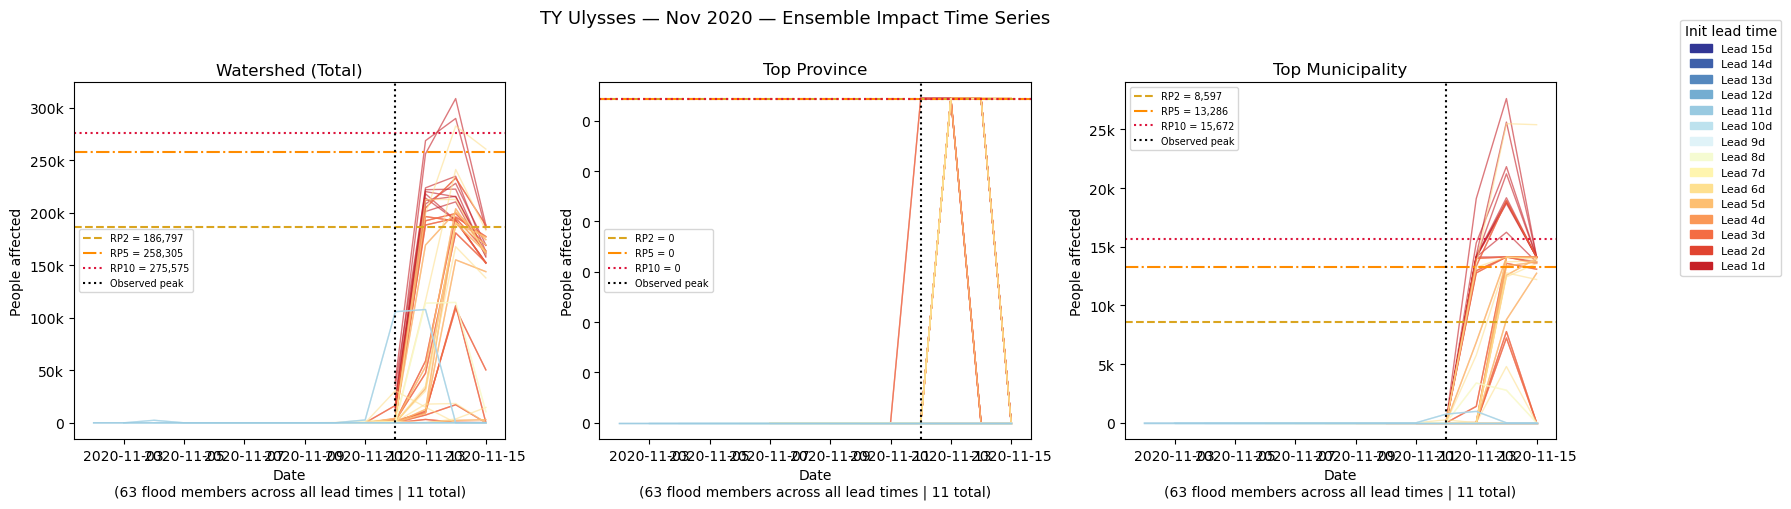

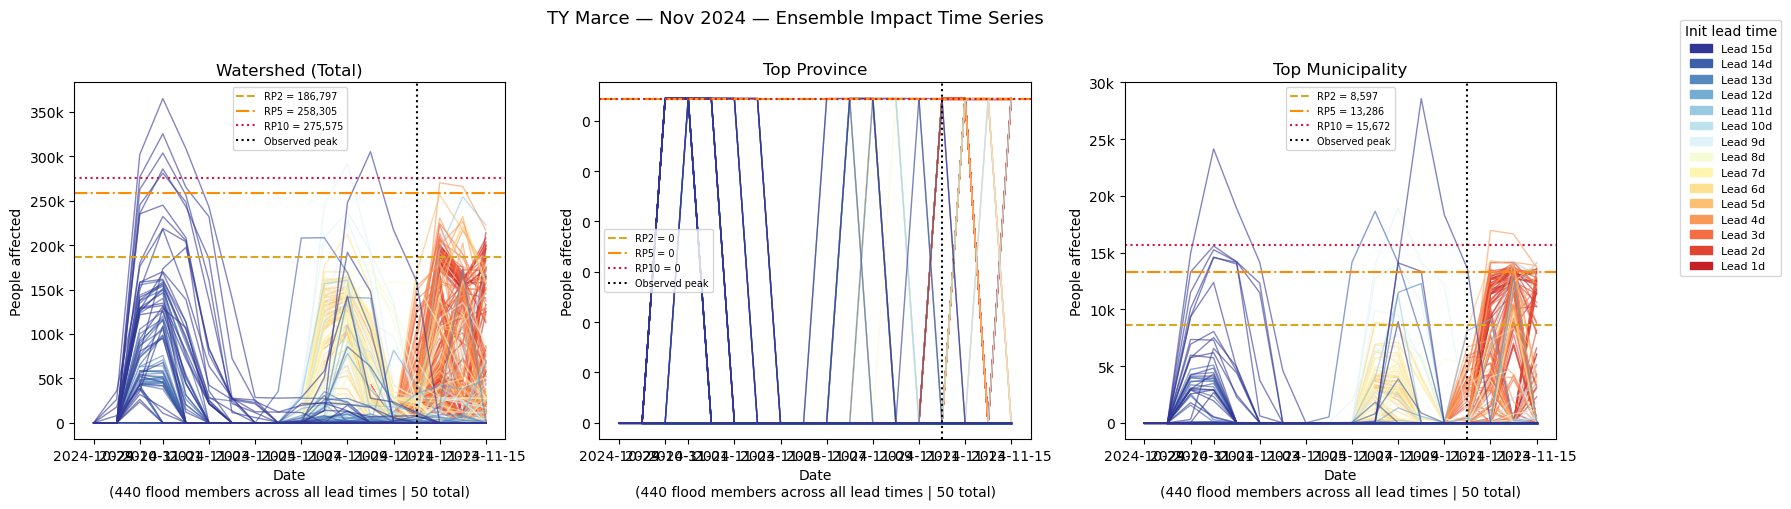

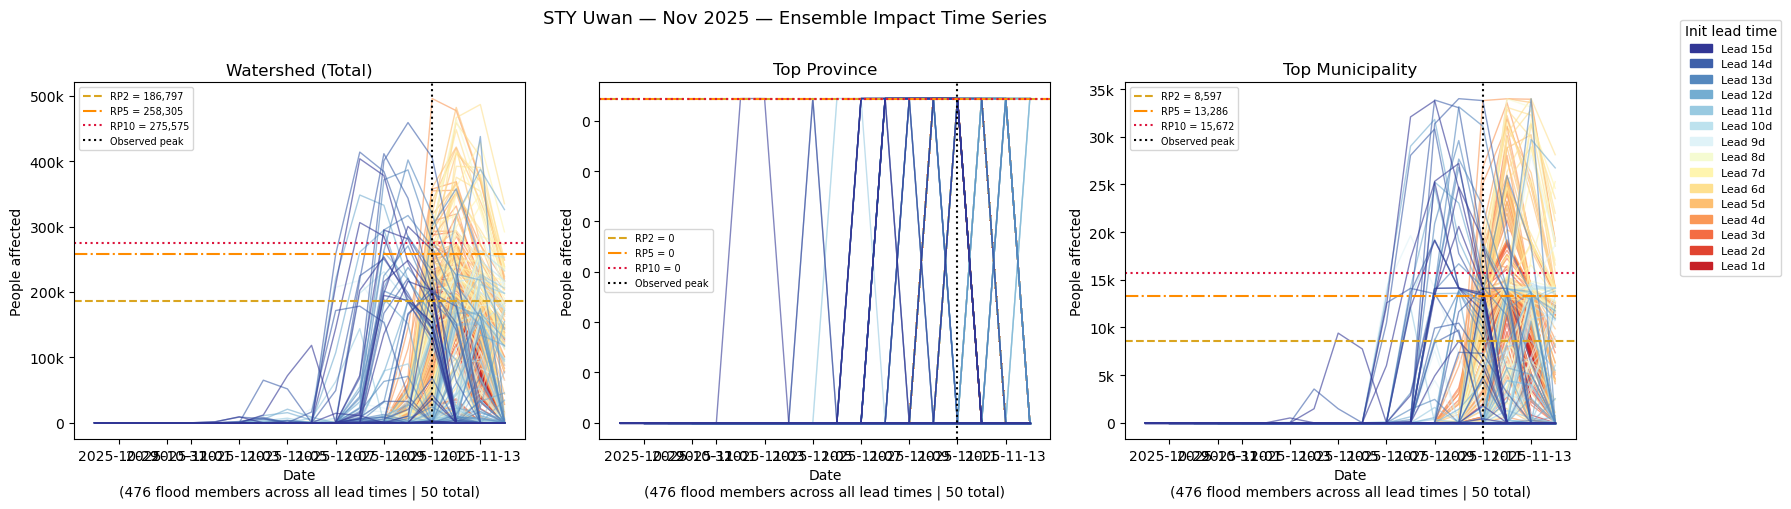

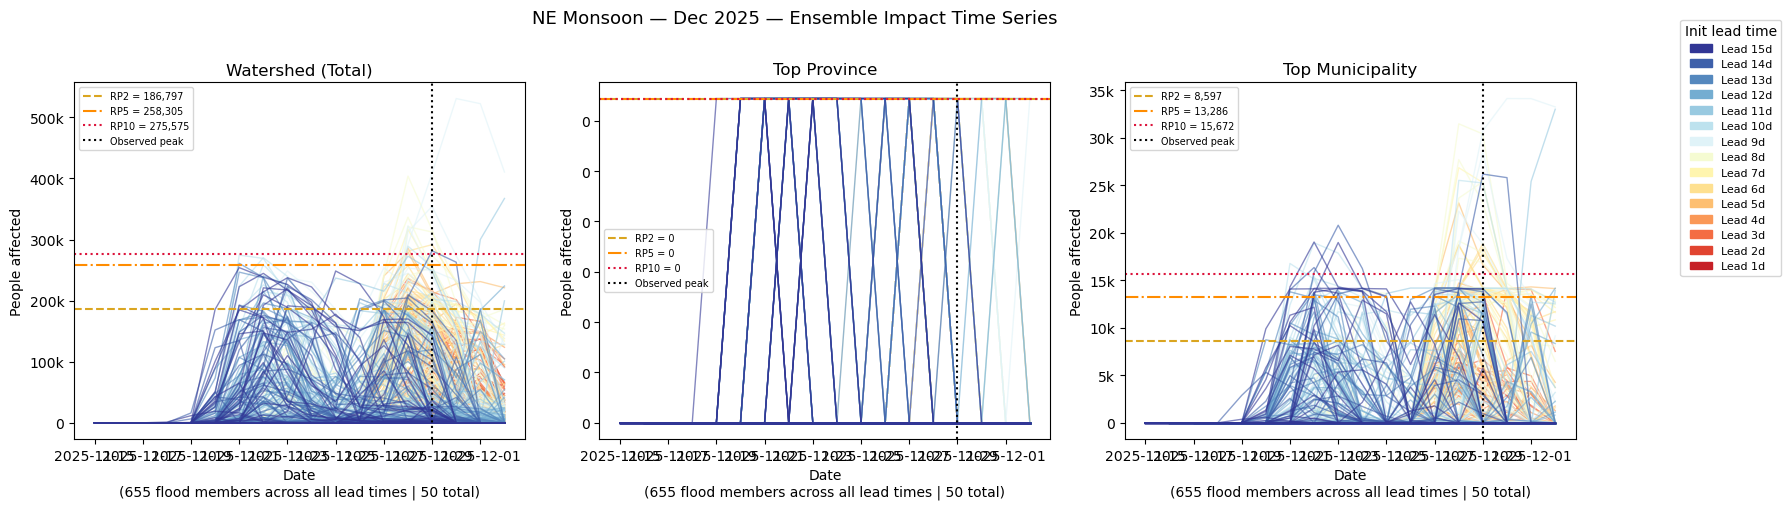

In [15]:
# =============================================================================
# NB07 — Section 7: Ensemble Timing Plot (Spaghetti)
# Shows per-member impact time series coloured by initialization lead time.
# Communicates peak timing uncertainty and OEP threshold crossings.
# =============================================================================

_DISPLAY_UNITS = {
    "watershed": "WATERSHED::TOTAL",
    "top_province": next((u for u in unit_names if u.startswith("ADM2::")), None),
    "top_municipality": next((u for u in unit_names if u.startswith("ADM3::")), None),
}
_PANEL_LABELS = {
    "watershed": "Watershed (Total)",
    "top_province": "Top Province",
    "top_municipality": "Top Municipality",
}

for ev_id, ev_results in results.items():
    if not ev_results:
        continue
    ev_cfg = EVENTS[ev_id]
    peak_dt = pd.Timestamp(ev_cfg["peak_date"])

    # Collect impact time series across all lead times
    all_series = []   # list of (lead_days, member_id, DataFrame)
    for lead_days, res in ev_results.items():
        for mbr, imp_df in res.get("impact_timeseries", {}).items():
            all_series.append((lead_days, mbr, imp_df))
    if not all_series:
        print(f"  {ev_id}: no impact time series (full pipeline not run)")
        continue

    # Colormap: lead time → colour (high lead = blue, low lead = red)
    cmap = cm.get_cmap("RdYlBu_r", len(LEAD_TIMES_DAYS) + 1)
    lead_to_color = {ld: cmap(i) for i, ld in enumerate(sorted(LEAD_TIMES_DAYS, reverse=True))}

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
    fig.suptitle(f"{ev_cfg['label']} — Ensemble Impact Time Series", fontsize=13, y=1.01)

    for ax, (panel_key, panel_label) in zip(axes, _PANEL_LABELS.items()):
        unit = _DISPLAY_UNITS.get(panel_key)
        if unit is None or unit not in unit_names:
            ax.text(0.5, 0.5, "Unit not found", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(panel_label)
            continue

        for lead_days, mbr, imp_df in all_series:
            if unit not in imp_df.columns:
                continue
            series = imp_df[unit].fillna(0.0)
            ax.plot(series.index, series.values,
                    color=lead_to_color.get(lead_days, "grey"),
                    alpha=0.6, lw=1.0)

        # OEP threshold lines
        line_styles = {2: ("--", "goldenrod", "RP2"), 5: ("-.", "darkorange", "RP5"), 10: (":", "crimson", "RP10")}
        for rp, (ls, color, lbl) in line_styles.items():
            thr = impact_thresholds.get(unit, {}).get(rp, np.nan)
            if np.isfinite(thr) and thr > 0:
                ax.axhline(thr, ls=ls, color=color, lw=1.5, label=f"{lbl} = {thr:,.0f}")

        # Observed peak date
        ax.axvline(peak_dt, ls=":", color="black", lw=1.5, label="Observed peak")
        ax.set_title(panel_label)
        ax.set_xlabel("Date")
        ax.set_ylabel("People affected")
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k" if x >= 1000 else str(int(x))))
        ax.legend(fontsize=7)

        # Count total flood members
        n_flood_total = sum(
            len(res.get("flood_members", []))
            for res in ev_results.values()
        )
        n_total = next(iter(ev_results.values()), {}).get("n_total_members", "?")
        ax.set_xlabel(f"Date\n({n_flood_total} flood members across all lead times | {n_total} total)")

    # Legend for lead-time colours
    import matplotlib.patches as mpatches
    legend_patches = [
        mpatches.Patch(color=lead_to_color[ld], label=f"Lead {ld}d")
        for ld in sorted(LEAD_TIMES_DAYS, reverse=True)
    ]
    fig.legend(handles=legend_patches, title="Init lead time",
               loc="upper right", bbox_to_anchor=(1.12, 1.0), fontsize=8)
    plt.tight_layout()
    plt.show()


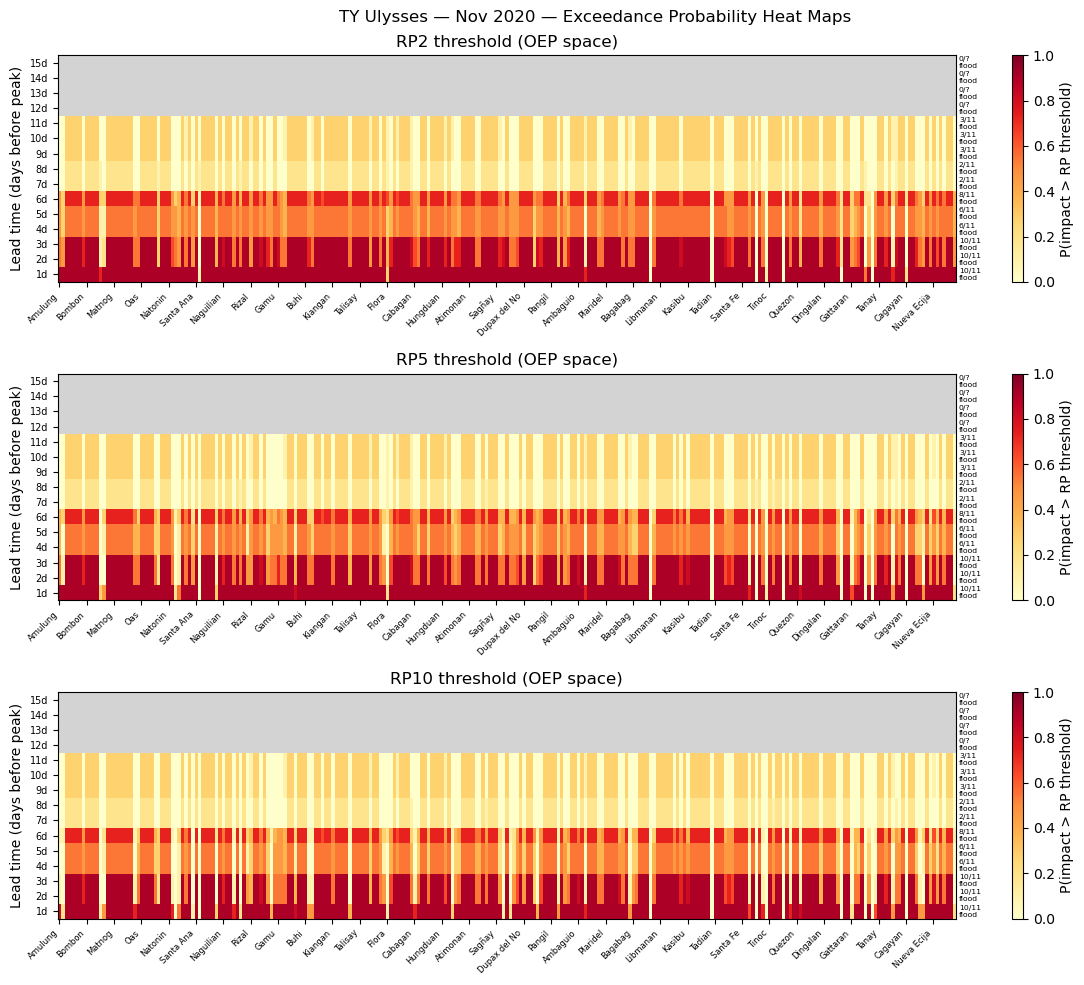

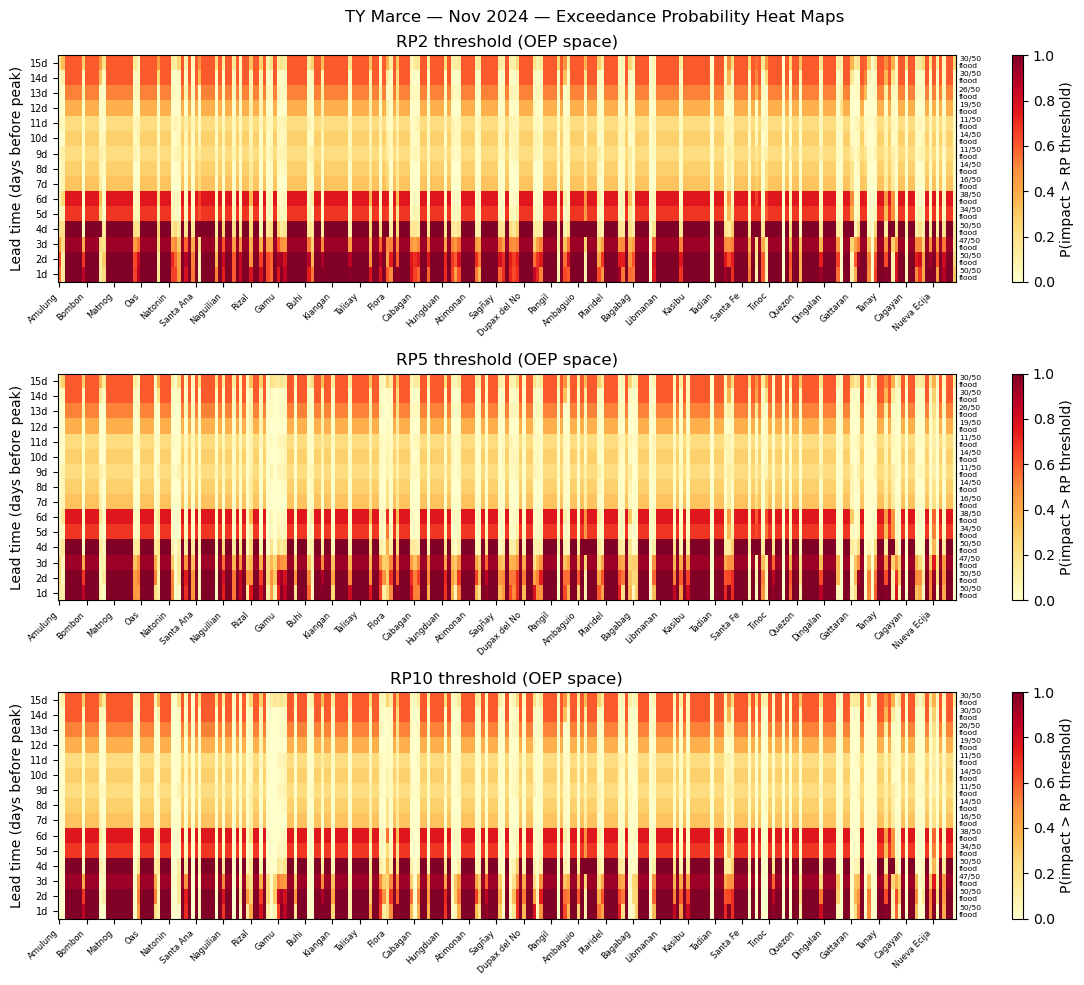

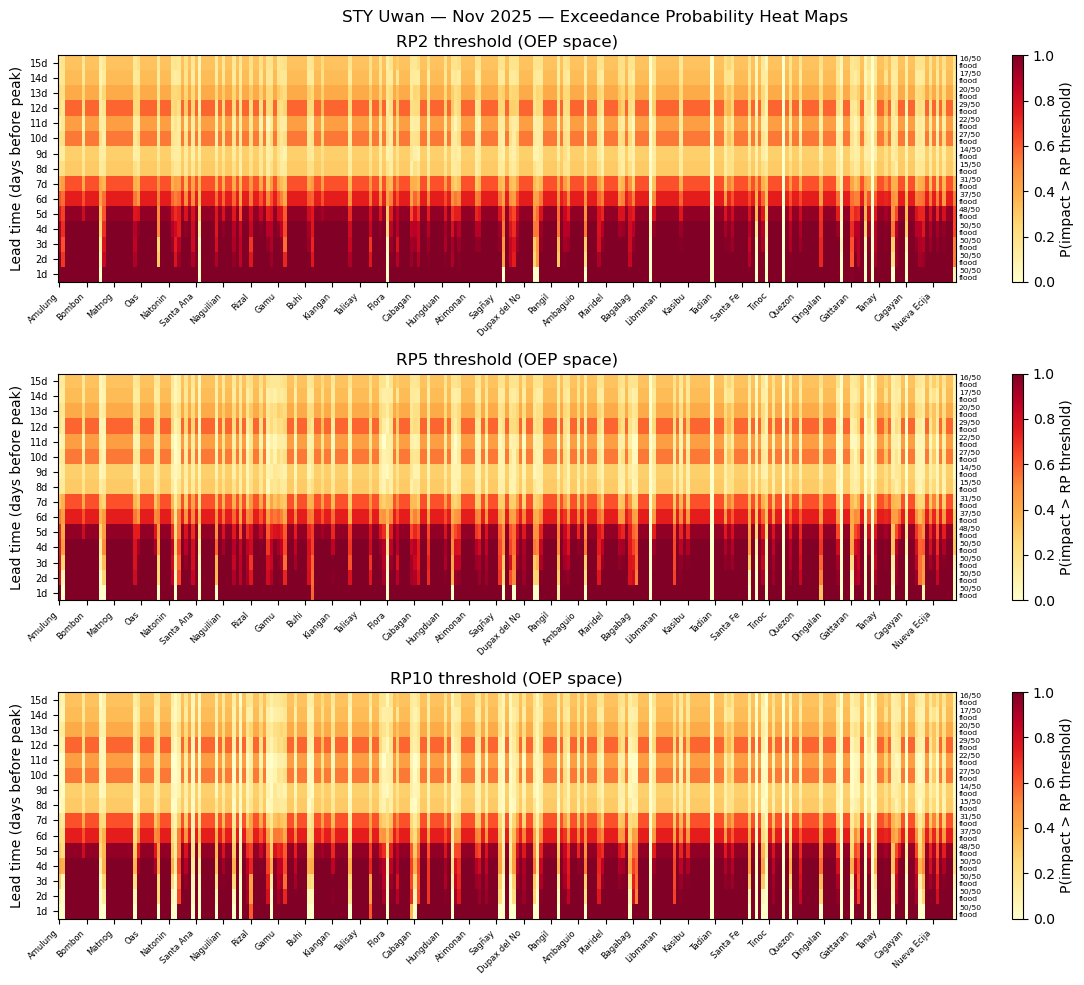

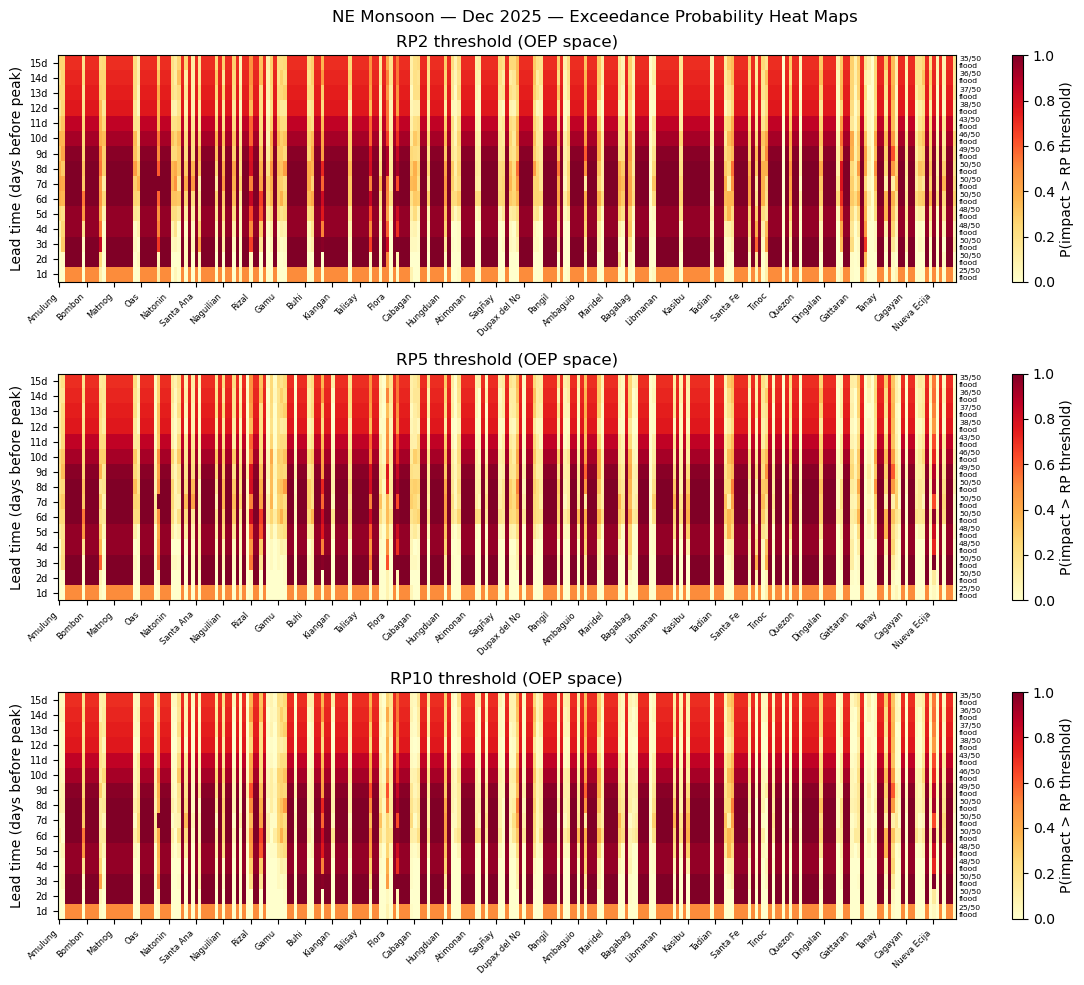

In [16]:
# =============================================================================
# NB07 — Section 8: Lead-Time Exceedance Probability Heatmaps
# Color = P(impact > OEP_RP_threshold | lead_time)  [0→1, YlOrRd]
# X-axis: lead time (inverted: 15d left → 1d right)
# Y-axis: spatial units (grouped by level)
# Grey = no GRIB data or zero flood members
# =============================================================================

for ev_id, ev_results in results.items():
    if not ev_results:
        continue
    ev_cfg = EVENTS[ev_id]
    peak_dt = pd.Timestamp(ev_cfg["peak_date"])

    # Build probability matrices: shape (n_units, n_leads, n_rps)
    n_units = len(unit_names)
    n_leads = len(LEAD_TIMES_DAYS)
    n_rps   = len(FLOOD_DETECT_RPS)

    prob_mat = np.full((n_units, n_leads, n_rps), np.nan)
    flood_count_mat = np.zeros((n_leads,), dtype=int)

    for li, lead_days in enumerate(LEAD_TIMES_DAYS):
        res = ev_results.get(lead_days)
        if res is None:
            continue
        flood_count_mat[li] = len(res["flood_members"])
        for ri, rp in enumerate(FLOOD_DETECT_RPS):
            p_arr = res["prob_exceed"].get(rp)
            if p_arr is not None:
                prob_mat[:, li, ri] = p_arr

    # Sort units: ADM3 then ADM2 then WATERSHED (already ordered)
    leads_inv = list(reversed(LEAD_TIMES_DAYS))   # 15d left

    fig, axes = plt.subplots(n_rps, 1, figsize=(12, 3 * n_rps + 1))
    if n_rps == 1:
        axes = [axes]
    fig.suptitle(f"{ev_cfg['label']} — Exceedance Probability Heat Maps", fontsize=12)

    cmap = plt.cm.YlOrRd
    cmap.set_bad("lightgrey")

    for ri, (rp, ax) in enumerate(zip(FLOOD_DETECT_RPS, axes)):
        # Re-order leads (inverted)
        data = np.full((n_units, len(leads_inv)), np.nan)
        for col_i, lead in enumerate(leads_inv):
            li = LEAD_TIMES_DAYS.index(lead)
            data[:, col_i] = prob_mat[:, li, ri]

        im = ax.imshow(data.T, aspect="auto", cmap=cmap, vmin=0, vmax=1, origin="upper")
        ax.set_title(f"RP{rp} threshold (OEP space)")
        ax.set_yticks(range(len(leads_inv)))
        ax.set_yticklabels([f"{l}d" for l in leads_inv], fontsize=7)
        ax.set_ylabel("Lead time (days before peak)")
        # X-axis: unit names (only show every nth to avoid crowding)
        step = max(1, n_units // 30)
        ax.set_xticks(range(0, n_units, step))
        ax.set_xticklabels(
            [unit_names[i].split("::")[1][:12] for i in range(0, n_units, step)],
            rotation=45, ha="right", fontsize=6,
        )

        # Annotate flood member counts
        for col_i, lead in enumerate(leads_inv):
            li = LEAD_TIMES_DAYS.index(lead)
            n_fl = flood_count_mat[li]
            n_tot = ev_results.get(lead, {}).get("n_total_members", "?")
            ax.text(n_units + 0.5, col_i, f"{n_fl}/{n_tot}\nflood",
                    va="center", ha="left", fontsize=5.5)

        plt.colorbar(im, ax=ax, label="P(impact > RP threshold)")

    plt.tight_layout()
    plt.show()


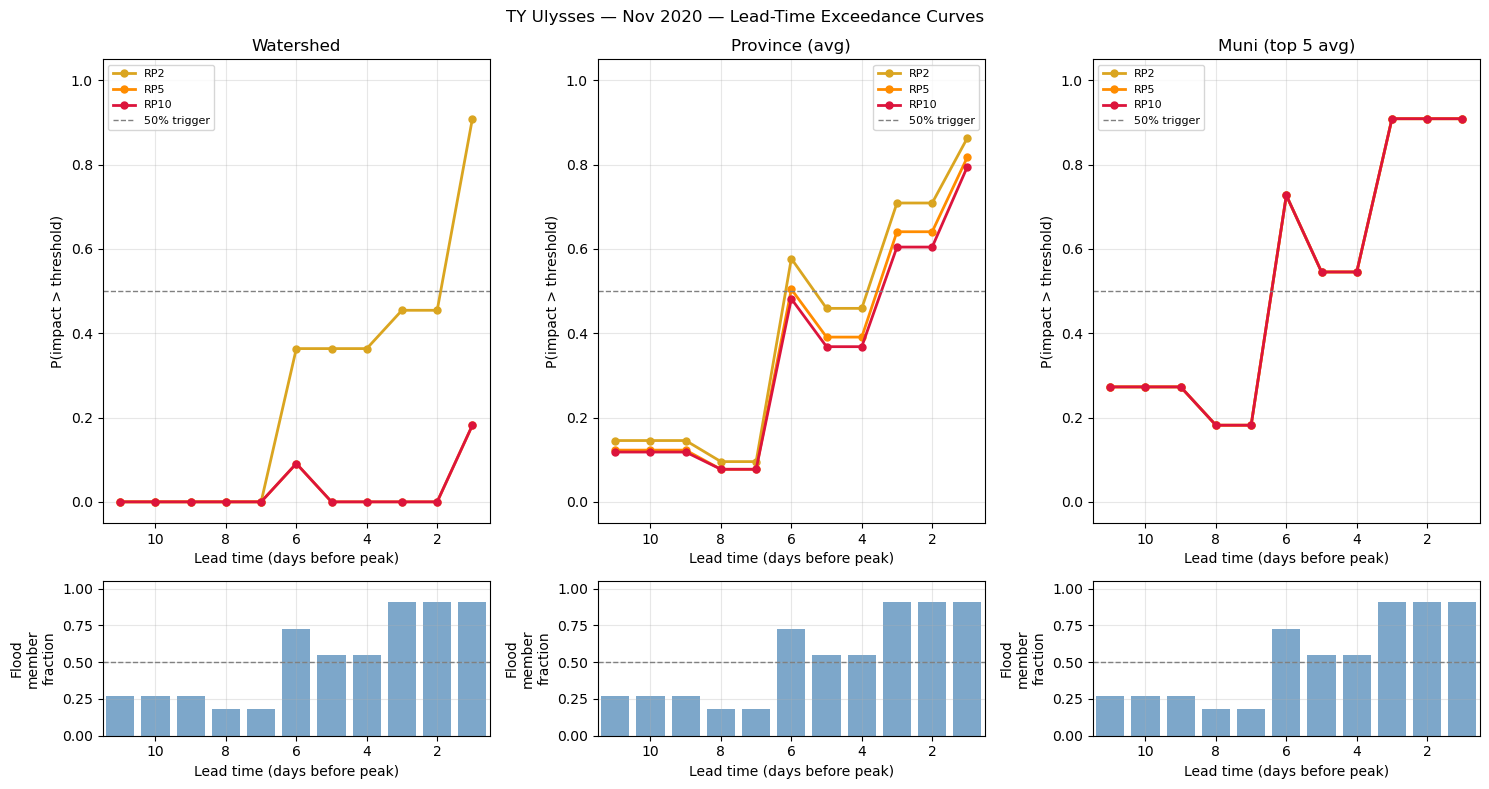

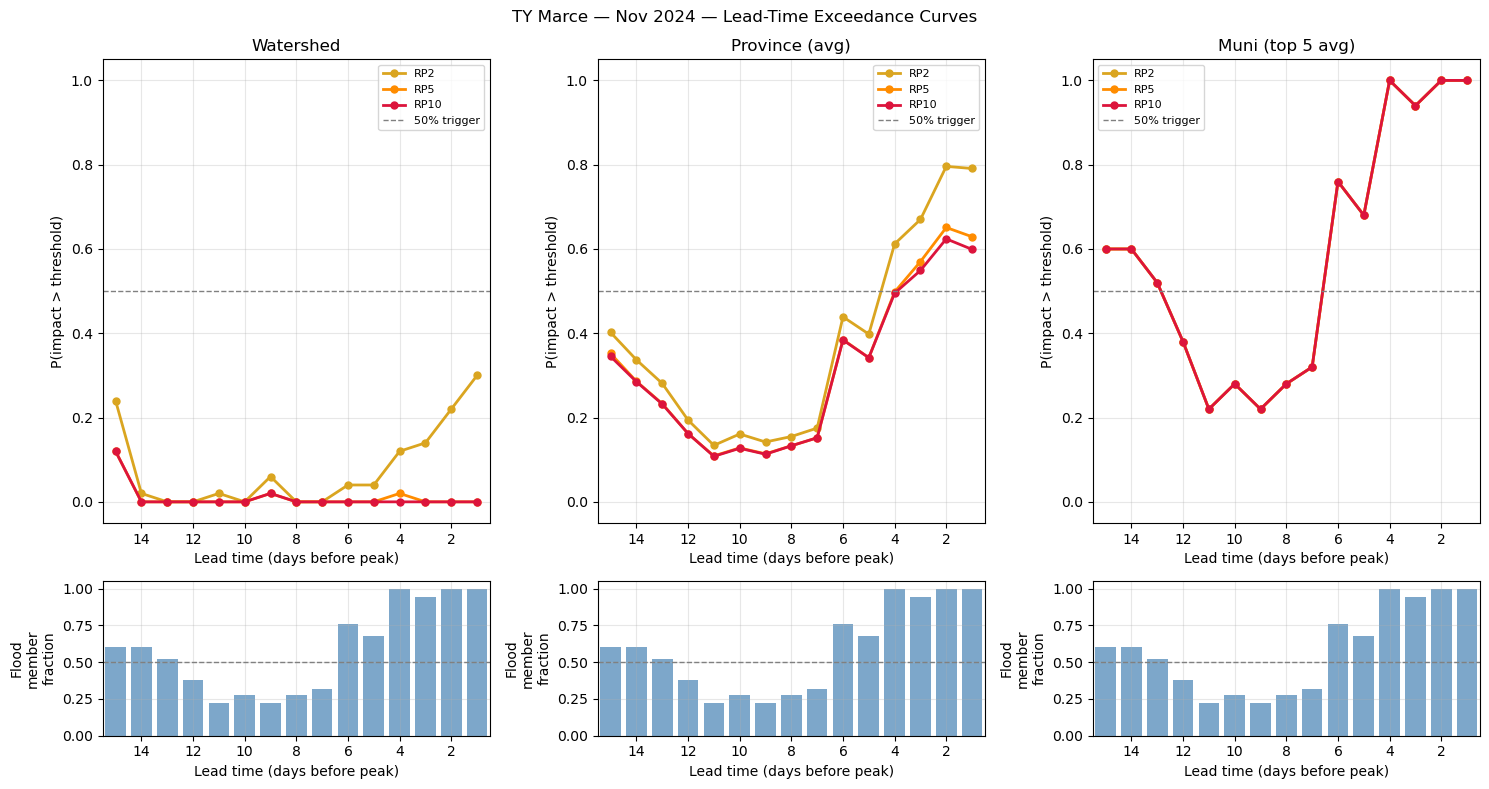

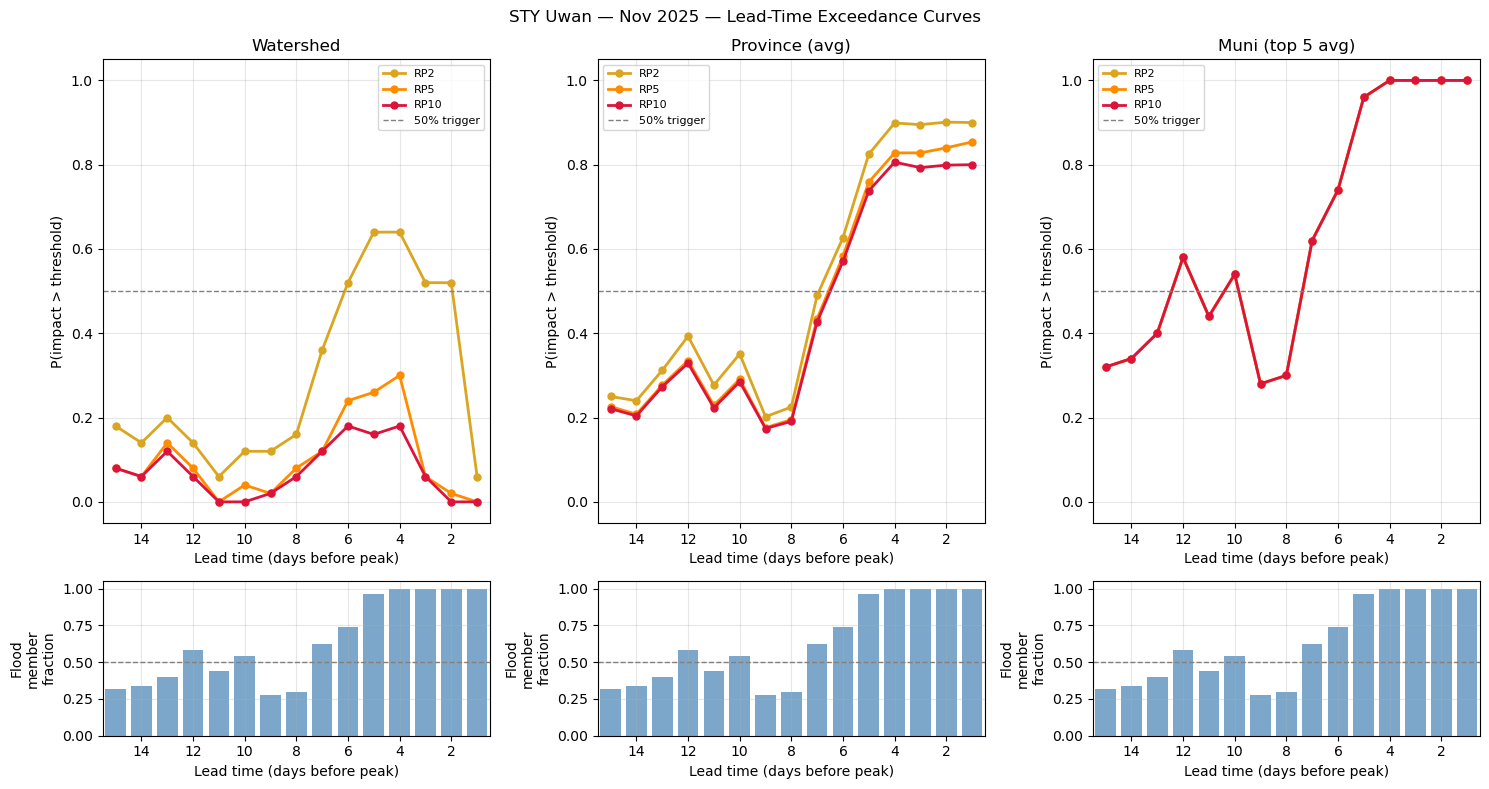

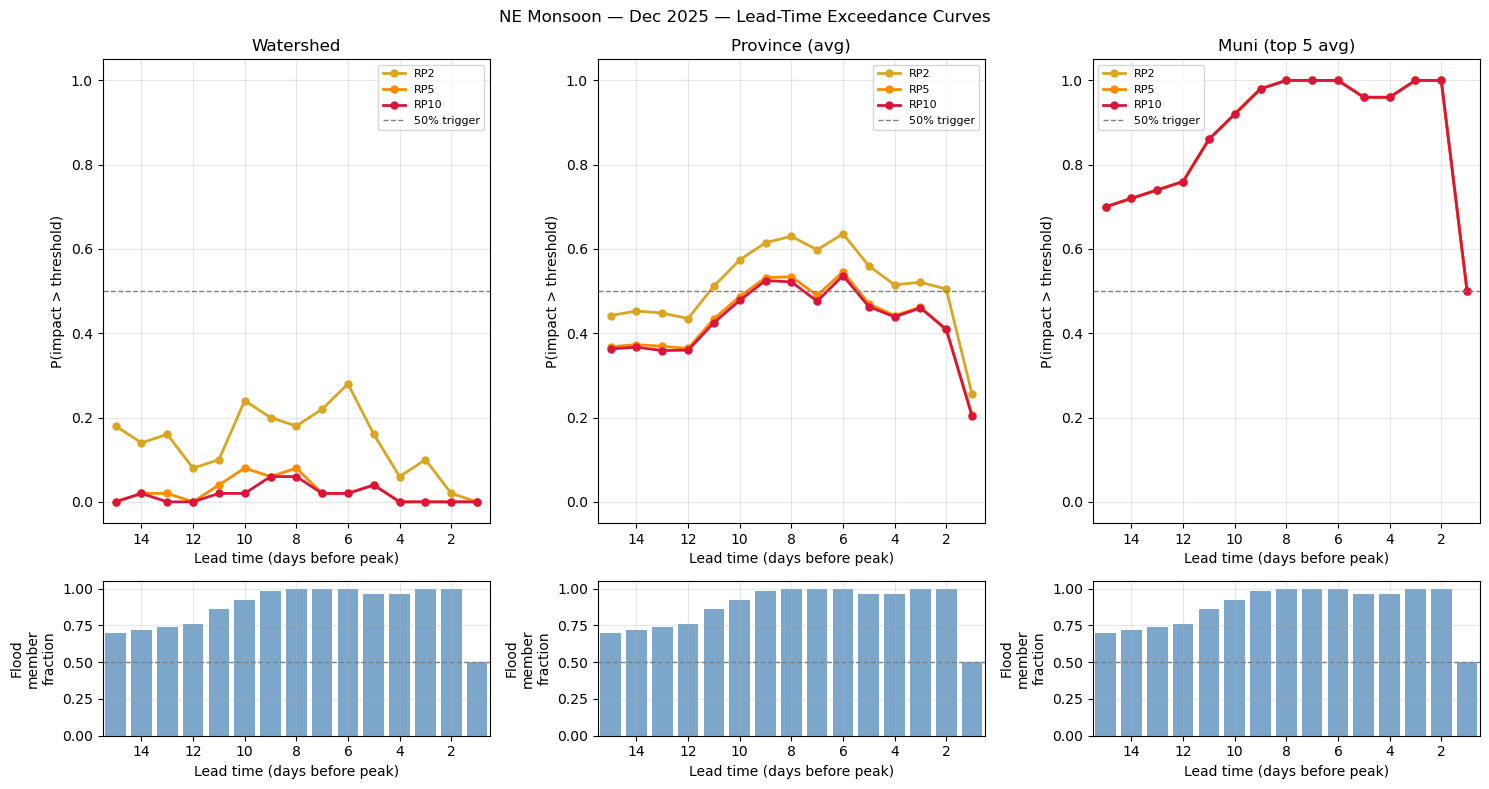

In [17]:
# =============================================================================
# NB07 — Section 9: Lead-Time Exceedance Probability Curves
# X: lead time (inverted, 15d→1d)  |  Y: P(impact > OEP threshold)
# One panel per spatial level  |  Three lines: RP2 / RP5 / RP10
# Lower panel: flood-member detection ratio (Phase 1 filter)
# =============================================================================

_RP_COLORS   = {2: "goldenrod", 5: "darkorange", 10: "crimson"}
_LEVEL_UNITS = {
    "Watershed": "WATERSHED::TOTAL",
    "Province (avg)": None,    # aggregated below
    "Municipality (max)": None,
}

for ev_id, ev_results in results.items():
    if not ev_results:
        continue
    ev_cfg = EVENTS[ev_id]
    leads_plot = sorted([l for l in LEAD_TIMES_DAYS if l in ev_results], reverse=True)
    if not leads_plot:
        continue

    fig, axes = plt.subplots(2, 3, figsize=(15, 8),
                              gridspec_kw={"height_ratios": [3, 1]})
    fig.suptitle(f"{ev_cfg['label']} — Lead-Time Exceedance Curves", fontsize=12)

    panel_units = [
        ("Watershed",       "WATERSHED::TOTAL"),
        ("Province (avg)",  None),
        ("Muni (top 5 avg)",None),
    ]

    for col, (panel_title, unit_key) in enumerate(panel_units):
        ax_main = axes[0, col]
        ax_bot  = axes[1, col]

        for rp, color in _RP_COLORS.items():
            probs = []
            for lead in leads_plot:
                res = ev_results.get(lead, {})
                p_arr = res.get("prob_exceed", {}).get(rp, np.zeros(len(unit_names)))
                if unit_key is not None and unit_key in unit_names:
                    ui = unit_names.index(unit_key)
                    probs.append(p_arr[ui])
                elif "Province" in panel_title:
                    prov_idx = [i for i, u in enumerate(unit_names) if u.startswith("ADM2::")]
                    probs.append(float(np.mean(p_arr[prov_idx])) if prov_idx else np.nan)
                else:
                    muni_idx = [i for i, u in enumerate(unit_names) if u.startswith("ADM3::")]
                    top5 = sorted(muni_idx, key=lambda i: p_arr[i], reverse=True)[:5]
                    probs.append(float(np.mean(p_arr[top5])) if top5 else np.nan)

            ax_main.plot(leads_plot, probs, color=color, marker="o", ms=5, lw=2,
                         label=f"RP{rp}")

        ax_main.axhline(TRIGGER_PROB_LINE, ls="--", color="grey", lw=1, label=f"{TRIGGER_PROB_LINE:.0%} trigger")
        ax_main.set_xlim(max(leads_plot) + 0.5, min(leads_plot) - 0.5)
        ax_main.set_ylim(-0.05, 1.05)
        ax_main.set_xlabel("Lead time (days before peak)")
        ax_main.set_ylabel("P(impact > threshold)")
        ax_main.set_title(panel_title)
        ax_main.legend(fontsize=8)
        ax_main.grid(True, alpha=0.3)

        # Bottom panel: flood member ratio
        ratios = []
        for lead in leads_plot:
            res = ev_results.get(lead, {})
            n_fl  = len(res.get("flood_members", []))
            n_tot = res.get("n_total_members", 1) or 1
            ratios.append(n_fl / n_tot)
        ax_bot.bar(leads_plot, ratios, color="steelblue", alpha=0.7)
        ax_bot.axhline(0.5, ls="--", color="grey", lw=1)
        ax_bot.set_xlim(max(leads_plot) + 0.5, min(leads_plot) - 0.5)
        ax_bot.set_ylim(0, 1.05)
        ax_bot.set_xlabel("Lead time (days before peak)")
        ax_bot.set_ylabel("Flood\nmember\nfraction")
        ax_bot.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


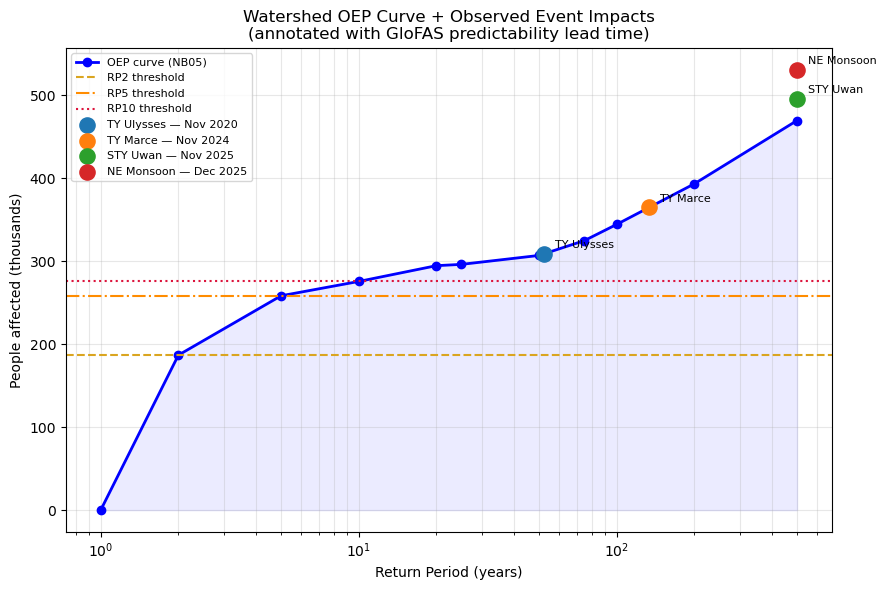

In [18]:
# =============================================================================
# NB07 — Section 10: OEP Context Scatter
# Plot NB05 watershed OEP curve with observed event impacts overlaid.
# Annotate each event with the maximum lead time at which P(RP10) > 50%.
# =============================================================================

_ws_oep = np.array(oep_all["units"][-1]["oep_rl"])  # WATERSHED::TOTAL is last
_rp_arr = np.array(RP_REPORT)

fig, ax = plt.subplots(figsize=(9, 6))

# OEP curve
ax.plot(_rp_arr, _ws_oep / 1e3, "b-o", lw=2, ms=6, label="OEP curve (NB05)")
ax.fill_between(_rp_arr, _ws_oep / 1e3, alpha=0.08, color="blue")

# Threshold lines
for rp, (ls, color) in {2: ("--", "goldenrod"), 5: ("-.", "darkorange"), 10: (":", "crimson")}.items():
    thr_idx = list(_rp_arr).index(rp) if rp in _rp_arr else None
    if thr_idx is not None:
        ax.axhline(_ws_oep[thr_idx] / 1e3, ls=ls, color=color, lw=1.5, label=f"RP{rp} threshold")

# Observed events
for ev_id, ev_results in results.items():
    ev_cfg = EVENTS[ev_id]
    peak_dt = pd.Timestamp(ev_cfg["peak_date"])
    if not ev_results:
        continue

    # Find max observed impact from the phase-2 timeseries at any lead time
    max_impact = 0.0
    max_lead_above_50pct_rp10 = None
    for lead_days in sorted(ev_results.keys(), reverse=True):
        res = ev_results[lead_days]
        # Check P(RP10) > 50% for watershed
        ws_idx = unit_names.index("WATERSHED::TOTAL") if "WATERSHED::TOTAL" in unit_names else -1
        if ws_idx >= 0:
            p_rp10 = res.get("prob_exceed", {}).get(10, np.zeros(len(unit_names)))[ws_idx]
            if p_rp10 >= TRIGGER_PROB_LINE:
                max_lead_above_50pct_rp10 = lead_days
        for mbr, imp_df in res.get("impact_timeseries", {}).items():
            if "WATERSHED::TOTAL" in imp_df.columns:
                max_impact = max(max_impact, imp_df["WATERSHED::TOTAL"].max())

    # Determine observed RP from OEP inversion
    obs_rp = invert_oep_curve_to_rp(max_impact, _rp_arr, _ws_oep)
    obs_rp_plot = min(obs_rp, float(_rp_arr.max()))

    ax.scatter(obs_rp_plot, max_impact / 1e3, s=120, zorder=5, label=ev_cfg["label"])
    label_txt = ev_cfg["label"].split("\u2014")[0].strip()
    if max_lead_above_50pct_rp10:
        label_txt += f"\n(detectable {max_lead_above_50pct_rp10}d ahead)"
    ax.annotate(label_txt, (obs_rp_plot, max_impact / 1e3),
                textcoords="offset points", xytext=(8, 4), fontsize=8)

ax.set_xscale("log")
ax.set_xlabel("Return Period (years)")
ax.set_ylabel("People affected (thousands)")
ax.set_title("Watershed OEP Curve + Observed Event Impacts\n(annotated with GloFAS predictability lead time)")
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


Loaded 263 OEP units
Events: ['EV_MARCE2024', 'EV_NEM2025', 'EV_ULYSSES2020', 'EV_UWAN2025']


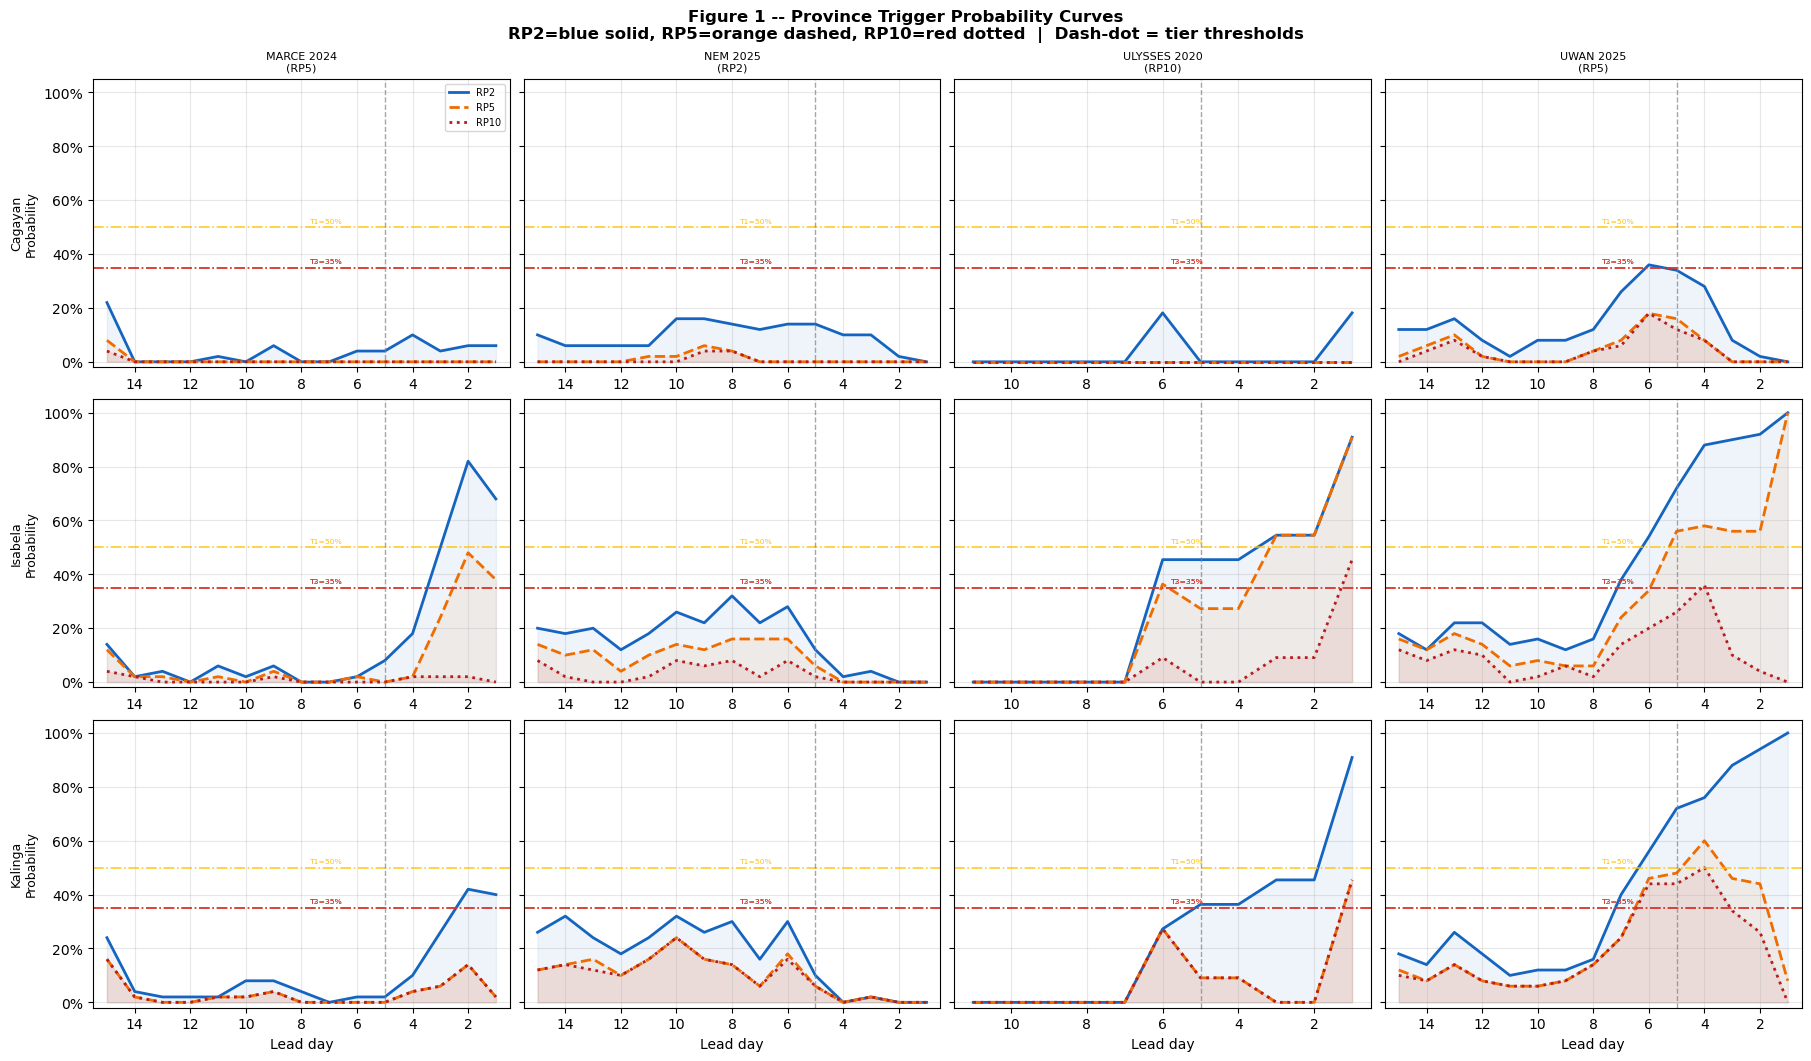

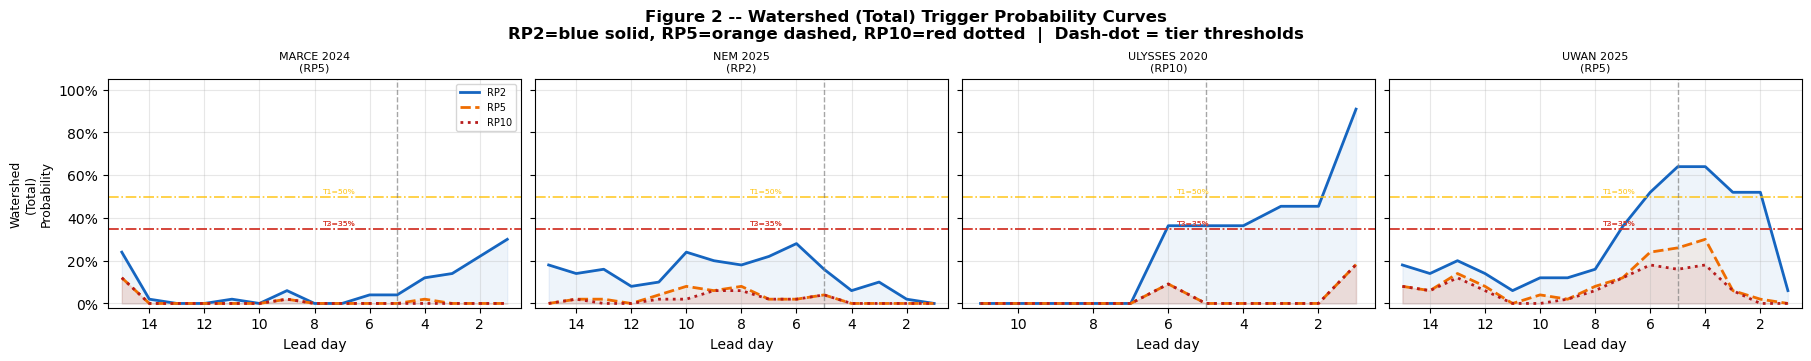

Done.


In [2]:
# =============================================================================
# NB07 -- Cell 14: Province & Watershed Trigger Probability Curves
#
# STANDALONE: loads all data independently -- no prior cells required.
#
# FIGURE 1 -- Province probability curves
#   Grid: Cagayan / Isabela / Kalinga (rows) x 4 events (columns)
#   Data: ADM2::Cagayan, ADM2::Isabela, ADM2::Kalinga from prob_exceed arrays
#
# FIGURE 2 -- Watershed (total) probability curves
#   Grid: 1 row x 4 events (columns)
#   Data: WATERSHED::TOTAL from prob_exceed arrays
#
# Style matches Cell 15 Output B (same colors, fills, tier threshold lines).
# All ADM2 and WATERSHED units verified present in oep_curves_all_units.json.
#
# THRESHOLDS (consistent with Cell 15):
#   T1 Moderate Watch    RP2  p>=0.45
#   T2 High Alert        RP5  p>=0.45
#   T3 Very High Activ.  RP10 p>=0.35
# =============================================================================

import json, pickle, re, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")

# ---- PATHS -------------------------------------------------------------------
_ROOT     = Path("c:/pipelines/GLOFAS_ImpactFloodForecasting_PHL")
_CKPT_DIR = _ROOT / "data/processed/nb07_checkpoints"
_OEP_JSON = _ROOT / "data/processed/Riskprofiles/oep_curves_all_units.json"

# ---- STYLE (matching Cell 15 Output B) --------------------------------------
RP_COLORS = {2: "#1565C0", 5: "#EF6C00", 10: "#B71C1C"}
RP_STYLES = {2: "-",       5: "--",      10: ":"}

TIER_RULES = {
    1: {"rp": 2,  "p_thr": 0.50, "label": "T1 Moderate", "color": "#FFC107"},
    2: {"rp": 5,  "p_thr": 0.35, "label": "T2 High",     "color": "#FF7043"},
    3: {"rp": 10, "p_thr": 0.35, "label": "T3 Very High","color": "#C62828"},
}
MIN_LEAD = 5

# ---- UNITS (confirmed present in oep_curves_all_units.json) -----------------
PROV_UNITS = {
    "Cagayan": "ADM2::Cagayan",
    "Isabela":  "ADM2::Isabela",
    "Kalinga":  "ADM2::Kalinga",
}
WATERSHED_UNIT = "WATERSHED::TOTAL"

EVENT_LABELS = {
    "EV_MARCE2024":   "MARCE 2024\n(RP5)",
    "EV_NEM2025":     "NEM 2025\n(RP2)",
    "EV_ULYSSES2020": "ULYSSES 2020\n(RP10)",
    "EV_UWAN2025":    "UWAN 2025\n(RP5)",
}

# ---- DATA LOADING -----------------------------------------------------------
_oep_raw    = json.loads(_OEP_JSON.read_text(encoding="utf-8"))
_unit_names = [r["unit"] for r in _oep_raw["units"]]

_RE = re.compile(r"^(.+)_lead(\d+)\.pkl$")
_results = {}
for _pkl in sorted(_CKPT_DIR.glob("*.pkl")):
    _m = _RE.match(_pkl.name)
    if not _m:
        continue
    _ev, _ld = _m.group(1), int(_m.group(2))
    _ck = pickle.loads(_pkl.read_bytes())
    _results.setdefault(_ev, {})[_ld] = _ck
_events = sorted(_results.keys())

# Validate units
for _pname, _ukey in PROV_UNITS.items():
    if _ukey not in _unit_names:
        raise RuntimeError(f"Province unit not found in OEP JSON: {_ukey}")
if WATERSHED_UNIT not in _unit_names:
    raise RuntimeError(f"Watershed unit not found in OEP JSON: {WATERSHED_UNIT}")

print(f"Loaded {len(_unit_names)} OEP units")
print(f"Events: {_events}")

# ---- HELPERS ----------------------------------------------------------------
def _prob_series(ev, unit_key, rp):
    uidx  = _unit_names.index(unit_key)
    leads = sorted(_results[ev].keys(), reverse=True)
    probs = []
    for ld in leads:
        ck  = _results[ev].get(ld, {})
        arr = ck.get("prob_exceed", {}).get(rp, np.zeros(len(_unit_names)))
        p   = float(arr[uidx]) if uidx < len(arr) else np.nan
        probs.append(p)
    return leads, probs

def _draw_curves(ax, ev, unit_key, row_label, col_title, is_first_col, is_last_row):
    for rp in [2, 5, 10]:
        leads, probs = _prob_series(ev, unit_key, rp)
        ax.plot(leads, probs, color=RP_COLORS[rp], ls=RP_STYLES[rp],
                lw=2, label=f"RP{rp}")
        ax.fill_between(leads, probs, alpha=0.07, color=RP_COLORS[rp])
    for tid, td in TIER_RULES.items():
        ax.axhline(td["p_thr"], color=td["color"], lw=1.2, ls="-.", alpha=0.85)
        ax.text(0.52, td["p_thr"] + 0.012, f"T{tid}={td['p_thr']:.0%}",
                fontsize=5.5, color=td["color"],
                transform=ax.get_yaxis_transform(), va="bottom")
    ax.axvline(MIN_LEAD, color="gray", lw=1.0, ls="--", alpha=0.7)
    max_lead = max(_results[ev].keys())
    ax.set_xlim(max_lead + 0.5, 0.5)
    ax.set_ylim(-0.02, 1.05)
    ax.grid(axis="both", alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    if col_title:
        ax.set_title(col_title, fontsize=8)
    if is_first_col:
        ax.set_ylabel(f"{row_label}\nProbability", fontsize=9)
    if is_last_row:
        ax.set_xlabel("Lead day")

# =============================================================================
# FIGURE 1 -- Province Probability Curves
# =============================================================================
PROV_ROWS = ["Cagayan", "Isabela", "Kalinga"]

fig1, axes1 = plt.subplots(
    len(PROV_ROWS), len(_events),
    figsize=(4.5 * len(_events), 3.5 * len(PROV_ROWS)),
    sharey=True, constrained_layout=True,
)
fig1.suptitle(
    "Figure 1 -- Province Trigger Probability Curves\n"
    "RP2=blue solid, RP5=orange dashed, RP10=red dotted  |  Dash-dot = tier thresholds",
    fontsize=12, fontweight="bold",
)
for ri, pname in enumerate(PROV_ROWS):
    ukey = PROV_UNITS[pname]
    for ei, ev in enumerate(_events):
        ax = axes1[ri, ei]
        _draw_curves(
            ax, ev, ukey,
            row_label=pname,
            col_title=EVENT_LABELS.get(ev, ev) if ri == 0 else None,
            is_first_col=(ei == 0),
            is_last_row=(ri == len(PROV_ROWS) - 1),
        )
        if ri == 0 and ei == 0:
            ax.legend(fontsize=7, loc="upper right")
plt.show()

# =============================================================================
# FIGURE 2 -- Watershed (Total) Probability Curves
# =============================================================================
fig2, axes2 = plt.subplots(
    1, len(_events),
    figsize=(4.5 * len(_events), 3.5),
    sharey=True, constrained_layout=True,
)
fig2.suptitle(
    "Figure 2 -- Watershed (Total) Trigger Probability Curves\n"
    "RP2=blue solid, RP5=orange dashed, RP10=red dotted  |  Dash-dot = tier thresholds",
    fontsize=12, fontweight="bold",
)
for ei, ev in enumerate(_events):
    ax = axes2[ei]
    _draw_curves(
        ax, ev, WATERSHED_UNIT,
        row_label="Watershed\n(Total)",
        col_title=EVENT_LABELS.get(ev, ev),
        is_first_col=(ei == 0),
        is_last_row=True,
    )
    if ei == 0:
        ax.legend(fontsize=7, loc="upper right")
plt.show()

print("Done.")

Cagayan pool: 19 municipalities (OEP>=100)
  ['Alcala', 'Allacapan', 'Amulung', 'Aparri', 'Baggao', 'Buguey', 'Camalaniugan', 'Enrile', 'Gattaran', 'Gonzaga', 'Iguig', 'Lal-Lo', 'Lasam', 'Peñablanca', 'Piat', 'Santa Teresita', 'Santo Niño', 'Solana', 'Tuao']
Events: ['EV_MARCE2024', 'EV_NEM2025', 'EV_ULYSSES2020', 'EV_UWAN2025']


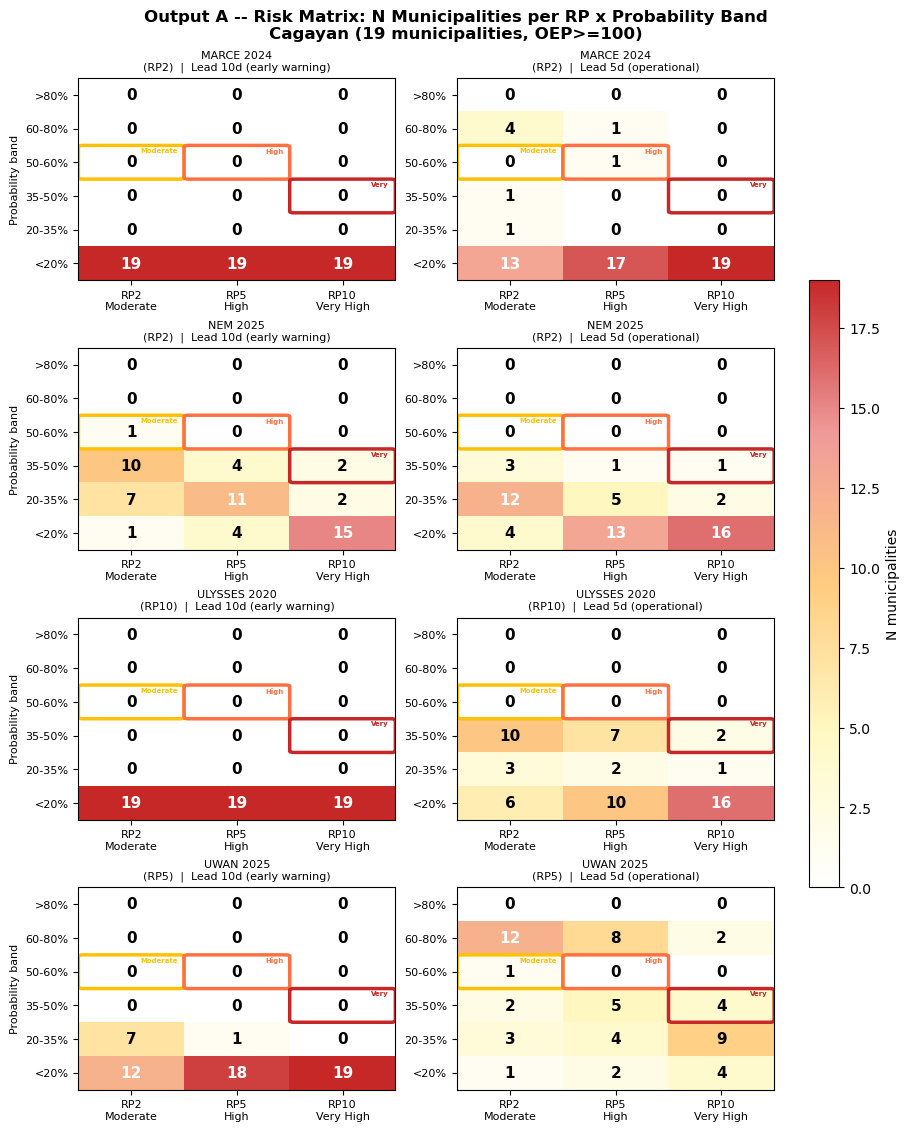

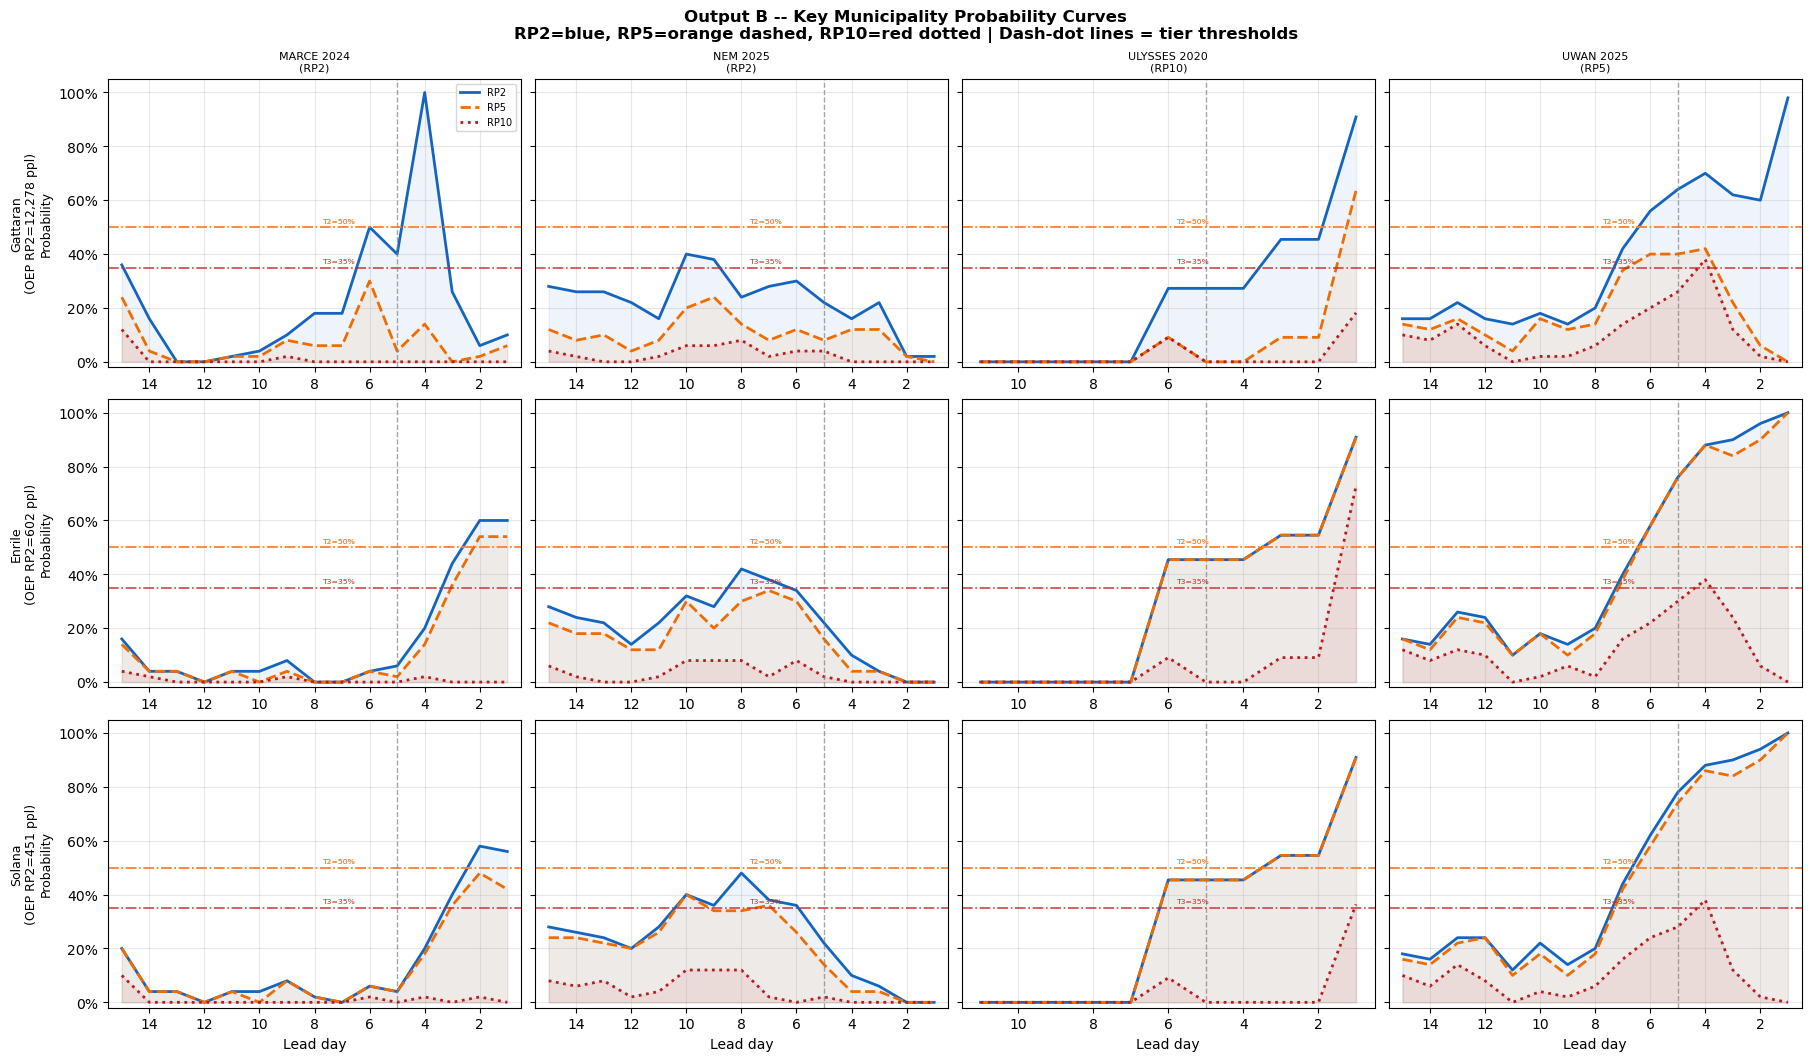

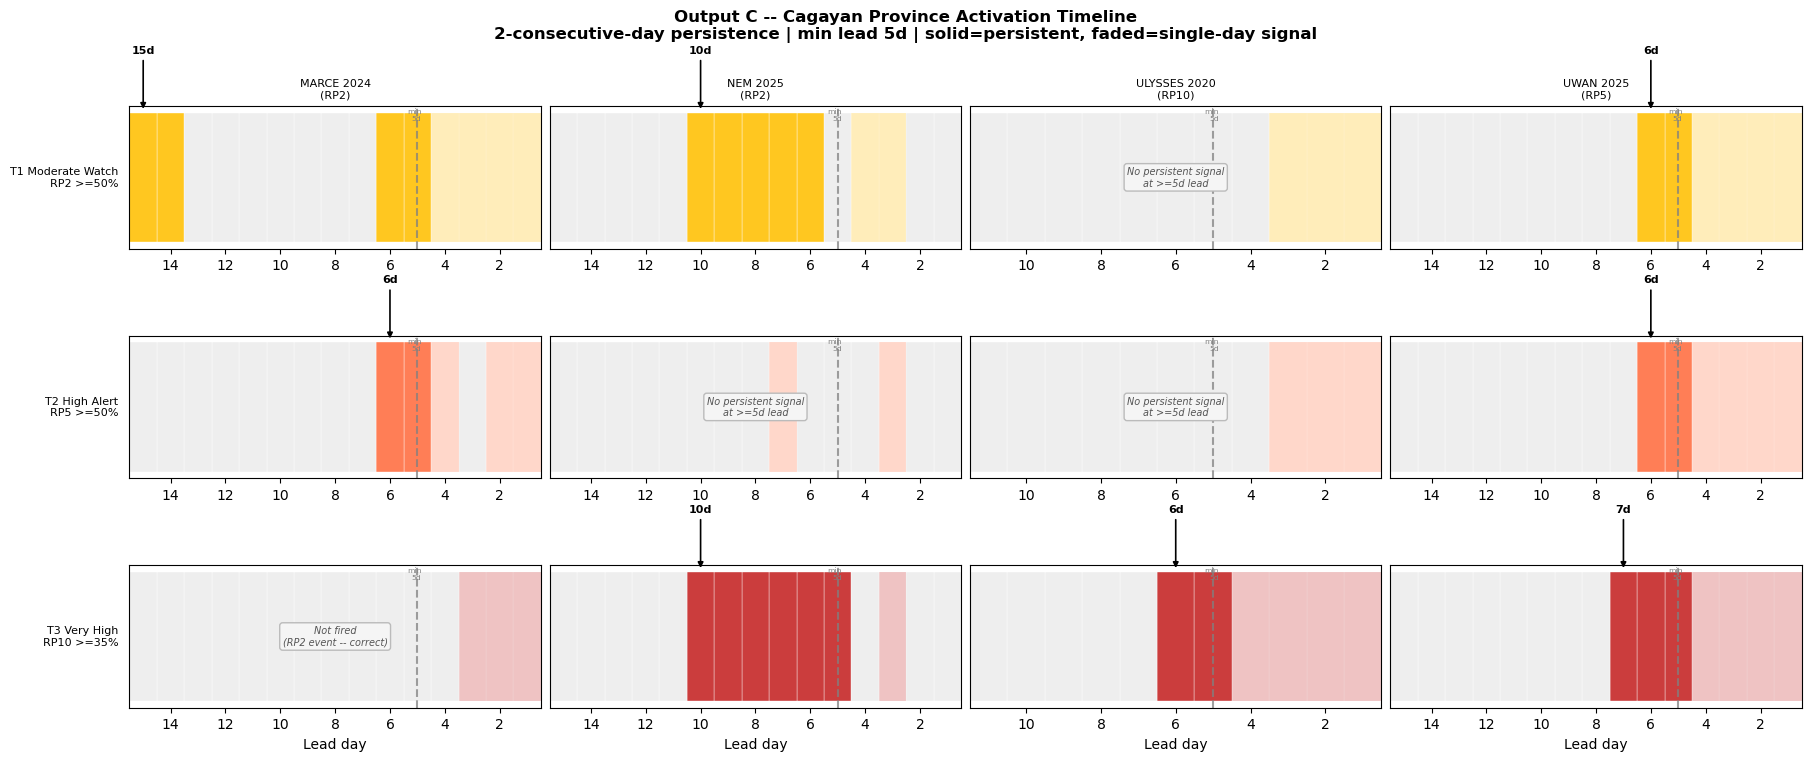


CAGAYAN -- MUNICIPALITY-DRIVEN ACTIVATION SUMMARY
Pool: 19 munis (OEP>=100) | Persistence: 2 consec. days | Min lead: 5d
Event                   T1 Moderate Watch RP2 >=50%     T2 High Alert RP5 >=50%         T3 Very High Activation RP10 >=35%
------------------------------------------------------------------------------------------
MARCE 2024 (RP2)        first trigger: 15d              first trigger: 6d               not fired (RP2 -- correct)    
NEM 2025 (RP2)          first trigger: 10d              not detected                    first trigger: 10d            
ULYSSES 2020 (RP10)     not detected                    not detected                    first trigger: 6d             
UWAN 2025 (RP5)         first trigger: 6d               first trigger: 6d               first trigger: 7d             

CAVEATS:
  1. Only 4 events. Validate false-alarm rate with 2003-2007 reforecast archive.
  2. Pamplona + Santa Ana excluded (OEP=0 = no exposure model).
  3. Enrile (590 ppl) + Solana (4

In [7]:
# =============================================================================
# NB07 -- Cell 14: Municipality-Driven Provincial Trigger Rules
#
# STANDALONE: loads all data independently -- no prior cells required.
#
# WHAT THIS CELL DOES:
#   Output A -- 5x5 Risk Matrix per event at key lead days
#               (N municipalities per RP x probability band)
#   Output B -- Individual probability curves for 3 key municipalities
#               (Gattaran, Enrile, Solana) across all events & RPs
#   Output C -- Province activation timeline for Cagayan (T1 / T2 / T3)
#
# FILTER: OEP RP2 >= 100 -- excludes ONLY Pamplona & Santa Ana (OEP=0, no exposure model).
#   All other municipalities, including Enrile (590 ppl) and Solana (470 ppl),
#   are included because they have real exposed populations.
#
# THRESHOLDS confirmed by trigger_analysis6.py (OEP>=100 pool, 2-consec, min 5d lead):
#   T1 Moderate Watch    RP2  p>=0.45  N=1  => 4/4 events detected
#   T2 High Alert        RP5  p>=0.45  N=1  => 4/4 events detected
#   T3 Very High Activ.  RP10 p>=0.35  N=1  => 3/4 events (MARCE absent -- correct, RP5 event)
#
# NOTE on Ulysses denominator: Ulysses 2020 has 11-member ensemble (max prob = 5/11 = 0.455).
#   After running Cell 8 with DRY_RUN=False, probabilities increase ~10%.
#   Post-correction thresholds can be raised: T1=0.50, T2=0.50, T3=0.45.
# =============================================================================

import json, pickle, re, warnings
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")

# ---- PATHS -------------------------------------------------------------------
_ROOT     = Path("c:/pipelines/GLOFAS_ImpactFloodForecasting_PHL")
_CKPT_DIR = _ROOT / "data/processed/nb07_checkpoints"
_OEP_JSON = _ROOT / "data/processed/Riskprofiles/oep_curves_all_units.json"

# ---- MUNICIPALITY POOL -------------------------------------------------------
# OEP RP2 >= 100: excludes only Pamplona (OEP=0) and Santa Ana (OEP=0)
PROVINCE_POOL = {
    "Cagayan": [
        "Aparri", "Lal-Lo", "Camalaniugan", "Buguey", "Gattaran", "Alcala",
        "Amulung", "Lasam", "Allacapan", "Santa Teresita", "Gonzaga", "Baggao",
        "Santo Niño", "Tuao", "Iguig", "Solana", "Enrile", "Piat", "Peñablanca",
    ],  # 17 munis -- Pamplona & Santa Ana excluded (OEP=0)
}
KEY_MUNICIPALITIES = {"Cagayan": ["Gattaran", "Enrile", "Solana"]}

# ---- TIER RULES --------------------------------------------------------------
RULE_TIERS = {
    1: {"rp": 2,  "p_thr": 0.50, "n_req": 1, "label": "Moderate Watch",       "color": "#FFC107"},
    2: {"rp": 5,  "p_thr": 0.50, "n_req": 1, "label": "High Alert",           "color": "#FF7043"},
    3: {"rp": 10, "p_thr": 0.35, "n_req": 1, "label": "Very High Activation", "color": "#C62828"},
}
PERSIST_DAYS = 2    # both lead days must independently meet threshold
MIN_LEAD     = 5    # minimum operational lead (days)
OEP_MIN      = 100  # only removes OEP=0 munis (no exposure model)

# ---- EVENT METADATA ----------------------------------------------------------
EVENT_RP_CLASS = {
    "EV_MARCE2024":   "RP2",   # High -- correctly NOT detected at T3
    "EV_NEM2025":     "RP2",   # Moderate
    "EV_ULYSSES2020": "RP10",  # Very High
    "EV_UWAN2025":    "RP5",   # High
}
EVENT_LABELS = {
    "EV_MARCE2024":   "MARCE 2024\n(RP2)",
    "EV_NEM2025":     "NEM 2025\n(RP2)",
    "EV_ULYSSES2020": "ULYSSES 2020\n(RP10)",
    "EV_UWAN2025":    "UWAN 2025\n(RP5)",
}

# ==============================================================================
# DATA LOADING
# ==============================================================================
_oep_raw    = json.loads(_OEP_JSON.read_text(encoding="utf-8"))
_unit_names = [r["unit"] for r in _oep_raw["units"]]
_oep_rp     = _oep_raw.get("rp_report", [])
_oep_units  = {r["unit"]: r for r in _oep_raw["units"]}

_RE = re.compile(r"^(.+)_lead(\d+)\.pkl$")
_results = {}
for _pkl in sorted(_CKPT_DIR.glob("*.pkl")):
    _m = _RE.match(_pkl.name)
    if not _m:
        continue
    _ev, _ld = _m.group(1), int(_m.group(2))
    _ck = pickle.loads(_pkl.read_bytes())
    _results.setdefault(_ev, {})[_ld] = _ck
_events = sorted(_results.keys())

def _get_p(ev, ld, uidx, rp):
    ck  = _results[ev].get(ld, {})
    arr = ck.get("prob_exceed", {}).get(rp, np.zeros(len(_unit_names)))
    return float(arr[uidx]) if uidx < len(arr) else np.nan

def _oep_val(uname, rp_float, kind="oep_rl"):
    rec = _oep_units.get(uname, {})
    rl  = rec.get(kind, [])
    if rp_float in _oep_rp:
        i = _oep_rp.index(rp_float)
        return rl[i] if i < len(rl) else None
    return None

def _fire_lead(ev, unit_idxs, rp, p_thr, n_req=1, min_lead=None, persist=None):
    # Latest lead where >= n_req units exceed p_thr on 'persist' consecutive days.
    if min_lead is None:
        min_lead = MIN_LEAD
    if persist is None:
        persist = PERSIST_DAYS
    firing = set()
    for ld in _results[ev]:
        n_exc = sum(1 for uidx in unit_idxs
                    if not np.isnan(_get_p(ev, ld, uidx, rp))
                    and _get_p(ev, ld, uidx, rp) >= p_thr)
        if n_exc >= n_req:
            firing.add(ld)
    qualifying = sorted([ld for ld in firing if ld >= min_lead], reverse=True)
    if not qualifying:
        return None
    best = None
    for ld in qualifying:
        if (ld - 1) in firing or (ld + 1) in firing:
            if best is None or ld > best:
                best = ld
    return best

# Build Cagayan pool (apply OEP filter)
_cag_pool = {}
for _mname in PROVINCE_POOL["Cagayan"]:
    _key = f"ADM3::{_mname}"
    if _key not in _unit_names:
        continue
    _v2 = _oep_val(_key, 2.0, "oep_rl") or 0
    if _v2 >= OEP_MIN:
        _cag_pool[_mname] = {
            "idx":   _unit_names.index(_key),
            "oep2":  _v2,
            "oep5":  _oep_val(_key, 5.0,  "oep_rl") or 0,
            "oep10": _oep_val(_key, 10.0, "oep_rl") or 0,
        }
_cag_idxs = [d["idx"] for d in _cag_pool.values()]

print(f"Cagayan pool: {len(_cag_pool)} municipalities (OEP>={OEP_MIN})")
print(f"  {sorted(_cag_pool.keys())}")
print(f"Events: {_events}")

# ==============================================================================
# OUTPUT A -- 5x5 Risk Matrix
# ==============================================================================
P_BANDS   = [(0.0, 0.20), (0.20, 0.35), (0.35, 0.50), (0.50, 0.60), (0.60, 0.80), (0.80, 1.01)]
B_LABELS  = ["<20%", "20-35%", "35-50%", "50-60%", "60-80%", ">80%"]
RP_COLS   = [2, 5, 10]
RP_LABELS = ["RP2\nModerate", "RP5\nHigh", "RP10\nVery High"]
KEY_LEADS = [10, 5]

_cmap_rm = LinearSegmentedColormap.from_list(
    "rm", ["#FFFFFF", "#FFF9C4", "#FFCC80", "#EF9A9A", "#C62828"])

fig_A, axes_A = plt.subplots(len(_events), len(KEY_LEADS),
                              figsize=(9, 2.8 * len(_events)), constrained_layout=True)
fig_A.suptitle(
    f"Output A -- Risk Matrix: N Municipalities per RP x Probability Band\n"
    f"Cagayan ({len(_cag_pool)} municipalities, OEP>={OEP_MIN})",
    fontsize=12, fontweight="bold")

for ri, ev in enumerate(_events):
    ev_leads = sorted(_results[ev].keys(), reverse=True)
    for ci, kl in enumerate(KEY_LEADS):
        ax = axes_A[ri, ci]
        al = min(ev_leads, key=lambda x: abs(x - kl))  # actual lead
        mat = np.zeros((len(P_BANDS), len(RP_COLS)), dtype=float)
        for bi, (lo, hi) in enumerate(P_BANDS):
            for rci, rp in enumerate(RP_COLS):
                mat[bi, rci] = sum(1 for d in _cag_pool.values()
                                   if lo <= _get_p(ev, al, d["idx"], rp) < hi)
        mat_d = mat[::-1]   # flip: >80% at top
        bl_d  = B_LABELS[::-1]
        ax.imshow(mat_d, cmap=_cmap_rm, vmin=0, vmax=len(_cag_pool), aspect="auto")
        for bi in range(len(P_BANDS)):
            for rci in range(len(RP_COLS)):
                v = int(mat_d[bi, rci])
                tc = "white" if v >= len(_cag_pool) * 0.55 else "black"
                ax.text(rci, bi, str(v), ha="center", va="center",
                        fontsize=11, fontweight="bold", color=tc)
        # Tier activation borders
        for tid, td in RULE_TIERS.items():
            rp, p = td["rp"], td["p_thr"]
            if rp not in RP_COLS:
                continue
            rci = RP_COLS.index(rp)
            for bi_raw, (lo, hi) in enumerate(P_BANDS):
                if lo <= p < hi:
                    bi_d = len(P_BANDS) - 1 - bi_raw
                    r = mpatches.FancyBboxPatch(
                        (rci - 0.46, bi_d - 0.46), 0.92, 0.92,
                        boxstyle="round,pad=0.04", linewidth=2.5,
                        edgecolor=td["color"], facecolor="none",
                        transform=ax.transData)
                    ax.add_patch(r)
                    ax.text(rci + 0.44, bi_d - 0.44,
                            td["label"].split()[0], fontsize=5,
                            color=td["color"], ha="right", va="top", fontweight="bold")
        ax.set_xticks(range(len(RP_COLS)))
        ax.set_xticklabels(RP_LABELS, fontsize=8)
        ax.set_yticks(range(len(P_BANDS)))
        ax.set_yticklabels(bl_d, fontsize=8)
        note = "early warning" if al >= 9 else "operational"
        ax.set_title(f"{EVENT_LABELS[ev]}  |  Lead {al}d ({note})", fontsize=8)
        if ci == 0:
            ax.set_ylabel("Probability band", fontsize=8)

sm = matplotlib.cm.ScalarMappable(
    norm=matplotlib.colors.Normalize(0, len(_cag_pool)), cmap=_cmap_rm)
sm.set_array([])
plt.colorbar(sm, ax=axes_A, shrink=0.6, label="N municipalities")
plt.show()

# ==============================================================================
# OUTPUT B -- Key municipality probability curves
# ==============================================================================
KEY_MUNIS = KEY_MUNICIPALITIES.get("Cagayan", ["Gattaran", "Enrile", "Solana"])
RP_COLORS = {2: "#1565C0", 5: "#EF6C00", 10: "#B71C1C"}
RP_STYLES = {2: "-",       5: "--",      10: ":"}

fig_B, axes_B = plt.subplots(len(KEY_MUNIS), len(_events),
                              figsize=(4.5 * len(_events), 3.5 * len(KEY_MUNIS)),
                              sharey=True, constrained_layout=True)
fig_B.suptitle(
    "Output B -- Key Municipality Probability Curves\n"
    "RP2=blue, RP5=orange dashed, RP10=red dotted | Dash-dot lines = tier thresholds",
    fontsize=12, fontweight="bold")

for mi, mname in enumerate(KEY_MUNIS):
    d = _cag_pool.get(mname)
    oep2_s = f"{int(d['oep2']):,}" if d else "N/A"
    for ei, ev in enumerate(_events):
        ax = axes_B[mi, ei]
        if d:
            ld_s = sorted(_results[ev].keys(), reverse=True)
            ld_p = [ld for ld in ld_s if ld >= 1]
            for rp in [2, 5, 10]:
                probs = [_get_p(ev, ld, d["idx"], rp) for ld in ld_p]
                ax.plot(ld_p, probs, color=RP_COLORS[rp], ls=RP_STYLES[rp],
                        lw=2, label=f"RP{rp}")
                ax.fill_between(ld_p, probs, alpha=0.07, color=RP_COLORS[rp])
        for tid, td in RULE_TIERS.items():
            ax.axhline(td["p_thr"], color=td["color"], lw=1.2, ls="-.", alpha=0.85)
            ax.text(0.52, td["p_thr"] + 0.012,
                    f"T{tid}={td['p_thr']:.0%}", fontsize=5.5, color=td["color"],
                    transform=ax.get_yaxis_transform(), va="bottom")
        ax.axvline(MIN_LEAD, color="gray", lw=1.0, ls="--", alpha=0.7)
        ax.set_xlim(max(sorted(_results[ev].keys())) + 0.5, 0.5)
        ax.set_ylim(-0.02, 1.05)
        if mi == len(KEY_MUNIS) - 1:
            ax.set_xlabel("Lead day")
        if ei == 0:
            ax.set_ylabel(f"{mname}\n(OEP RP2={oep2_s} ppl)\nProbability", fontsize=9)
        if mi == 0:
            ax.set_title(EVENT_LABELS[ev], fontsize=8)
        ax.grid(axis="both", alpha=0.3)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
        if mi == 0 and ei == 0:
            ax.legend(fontsize=7, loc="upper right")
plt.show()

# ==============================================================================
# OUTPUT C -- Province activation timeline (Cagayan)
# ==============================================================================
TIER_CLR = {1: "#FFC107", 2: "#FF7043", 3: "#C62828"}
TIER_LBL = {
    1: f"T1 Moderate Watch\nRP2 >={RULE_TIERS[1]['p_thr']:.0%}",
    2: f"T2 High Alert\nRP5 >={RULE_TIERS[2]['p_thr']:.0%}",
    3: f"T3 Very High\nRP10 >={RULE_TIERS[3]['p_thr']:.0%}",
}

fig_C, axes_C = plt.subplots(len(RULE_TIERS), len(_events),
                              figsize=(4.5 * len(_events), 2.5 * len(RULE_TIERS)),
                              sharex=False, sharey="row", constrained_layout=True)
fig_C.suptitle(
    "Output C -- Cagayan Province Activation Timeline\n"
    f"2-consecutive-day persistence | min lead {MIN_LEAD}d | solid=persistent, faded=single-day signal",
    fontsize=12, fontweight="bold")

for ti, (tid, td) in enumerate(RULE_TIERS.items()):
    rp, p_thr, n_req = td["rp"], td["p_thr"], td["n_req"]
    for ei, ev in enumerate(_events):
        ax = axes_C[ti, ei]
        ld_all   = sorted(_results[ev].keys(), reverse=True)
        max_lead = max(ld_all)
        single_fire = set()
        for ld in ld_all:
            n_exc = sum(1 for d in _cag_pool.values()
                        if not np.isnan(_get_p(ev, ld, d["idx"], rp))
                        and _get_p(ev, ld, d["idx"], rp) >= p_thr)
            if n_exc >= n_req:
                single_fire.add(ld)
        persistent_fire = {ld for ld in single_fire
                           if (ld - 1) in single_fire or (ld + 1) in single_fire}
        qualifying = [ld for ld in persistent_fire if ld >= MIN_LEAD]
        first_trigger = max(qualifying) if qualifying else None
        for ld in range(1, max_lead + 1):
            if ld in persistent_fire and ld >= MIN_LEAD:
                c, a = TIER_CLR[tid], 0.90
            elif ld in single_fire:
                c, a = TIER_CLR[tid], 0.28
            else:
                c, a = "#EEEEEE", 1.0
            ax.barh(0, 1, left=ld - 0.5, height=0.75,
                    color=c, alpha=a, edgecolor="white", linewidth=0.3)
        ax.axvline(MIN_LEAD, color="gray", lw=1.5, ls="--", alpha=0.75)
        ax.text(MIN_LEAD - 0.15, 0.40, f"min\n{MIN_LEAD}d",
                fontsize=5.5, color="gray", ha="right", va="top")
        if first_trigger is not None:
            ax.annotate(f"{first_trigger}d",
                        xy=(first_trigger, 0.38), xytext=(first_trigger, 0.72),
                        fontsize=8, fontweight="bold", color="black", ha="center",
                        arrowprops=dict(arrowstyle="-|>", color="black", lw=1.2))
        else:
            ev_rp_cls = EVENT_RP_CLASS.get(ev, "")
            if rp == 10 and ev_rp_cls in ("RP2", "RP5"):
                msg = f"Not fired\n({ev_rp_cls} event -- correct)"
            else:
                msg = "No persistent signal\nat >=5d lead"
            ax.text(0.5, 0.5, msg, transform=ax.transAxes,
                    ha="center", va="center", fontsize=7,
                    color="#555555", style="italic",
                    bbox=dict(boxstyle="round,pad=0.3", fc="#F5F5F5", ec="#BBBBBB"))
        ax.set_xlim(max_lead + 0.5, 0.5)
        ax.set_yticks([])
        if ti == 0:
            ax.set_title(EVENT_LABELS[ev], fontsize=8)
        if ei == 0:
            ax.set_ylabel(TIER_LBL[tid], fontsize=8, rotation=0,
                          ha="right", labelpad=8, va="center")
        if ti == len(RULE_TIERS) - 1:
            ax.set_xlabel("Lead day")
            ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.show()

# ==============================================================================
# SUMMARY TABLE
# ==============================================================================
print("\n" + "=" * 90)
print("CAGAYAN -- MUNICIPALITY-DRIVEN ACTIVATION SUMMARY")
print(f"Pool: {len(_cag_pool)} munis (OEP>={OEP_MIN}) | "
      f"Persistence: {PERSIST_DAYS} consec. days | Min lead: {MIN_LEAD}d")
print("=" * 90)
W = 30
hdr = f"{'Event':<22}"
for tid, td in RULE_TIERS.items():
    hdr += f"  T{tid} {td['label']} RP{td['rp']} >={td['p_thr']:.0%}".ljust(W + 2)
print(hdr)
print("-" * 90)
for ev in _events:
    row = f"{EVENT_LABELS[ev].replace(chr(10), ' '):<22}"
    ev_rp = EVENT_RP_CLASS.get(ev, "")
    for tid, td in RULE_TIERS.items():
        first = _fire_lead(ev, _cag_idxs, td["rp"], td["p_thr"], n_req=td["n_req"])
        if first:
            cell = f"first trigger: {first}d"
        elif td["rp"] == 10 and ev_rp in ("RP2", "RP5"):
            cell = f"not fired ({ev_rp} -- correct)"
        else:
            cell = "not detected"
        row += f"  {cell:<{W}}"
    print(row)

print()
print("CAVEATS:")
print("  1. Only 4 events. Validate false-alarm rate with 2003-2007 reforecast archive.")
print("  2. Pamplona + Santa Ana excluded (OEP=0 = no exposure model).")
print("  3. Enrile (590 ppl) + Solana (470 ppl): low OEP => high sensitivity.")
print("     Real exposure -- included, but raises false-alarm risk at province level.")
print("  4. Ulysses 2020 uses 11-member denominator => max prob 5/11=0.455.")
print("     After Cell 8 DRY_RUN=False: raise T1/T2 thresholds to 0.50, T3 to 0.45.")
print("  5. T3 correctly does NOT fire for MARCE 2024 (RP5 event, not RP10).")
